In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("urvishp80/irmas-training-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'irmas-training-data' dataset.
Path to dataset files: /kaggle/input/irmas-training-data


In [18]:
import os

DATASET_PATH = path  # Use the path from kagglehub.dataset_download

files = []
labels = []

for root, _, fs in os.walk(DATASET_PATH):
    for f in fs:
        if f.endswith(".wav"):
            files.append(os.path.join(root, f))
            labels.append(os.path.basename(root))

print("Total files:", len(files))
if files:
    print("Sample:", files[0])
else:
    print("No .wav files found in the dataset path.")

Total files: 6705
Sample: /kaggle/input/irmas-training-data/IRMAS-TrainingData/cla/[cla][jaz_blu]0285__3.wav


In [19]:
import pandas as pd

df = pd.DataFrame({
    "file": files,
    "label": labels
})
print(df.head())


                                                file label
0  /kaggle/input/irmas-training-data/IRMAS-Traini...   cla
1  /kaggle/input/irmas-training-data/IRMAS-Traini...   cla
2  /kaggle/input/irmas-training-data/IRMAS-Traini...   cla
3  /kaggle/input/irmas-training-data/IRMAS-Traini...   cla
4  /kaggle/input/irmas-training-data/IRMAS-Traini...   cla


In [20]:
from sklearn.model_selection import train_test_split

train_files, test_files, train_labels, test_labels = train_test_split(
    files,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

print("Train samples:", len(train_files))
print("Test samples:", len(test_files))


Train samples: 5364
Test samples: 1341


In [21]:
import librosa
import numpy as np

SR = 22050

def preprocess_audio(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SR, mono=False)

        # stereo → mono merge
        if y.ndim == 2:
            y = np.mean(y, axis=0)

        # trim silence
        y, _ = librosa.effects.trim(y, top_db=30)

        # skip silence clips
        if len(y) < SR:
            return None

        # normalize
        y = librosa.util.normalize(y)

        return y

    except Exception as e:
        print("Error:", file_path)
        return None


In [22]:
sample_audio = train_files[0]

y = preprocess_audio(sample_audio)

if y is None:
    print("Skipped silent file")
else:
    print("Loaded OK")
    print("Duration:", len(y)/SR, "sec")
    print("Mono:", y.ndim == 1)


Loaded OK
Duration: 3.0 sec
Mono: True


In [23]:
import librosa
import numpy as np

def make_mel_log(y, sr=SR):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db


In [24]:
import matplotlib.pyplot as plt
import librosa.display

def save_mel_image(mel_db, save_path):
    plt.figure(figsize=(6,4))

    librosa.display.specshow(
        mel_db,
        sr=SR,
        x_axis="time",
        y_axis="mel"
    )

    plt.colorbar(format="%+2.0f dB")
    plt.title("Mel Log Spectrogram")
    plt.tight_layout()

    plt.savefig(save_path)
    plt.show()
    plt.close()


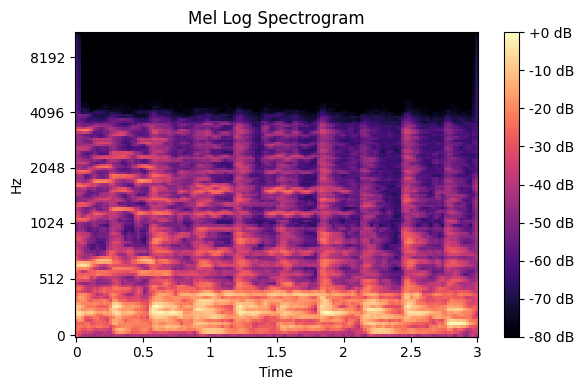

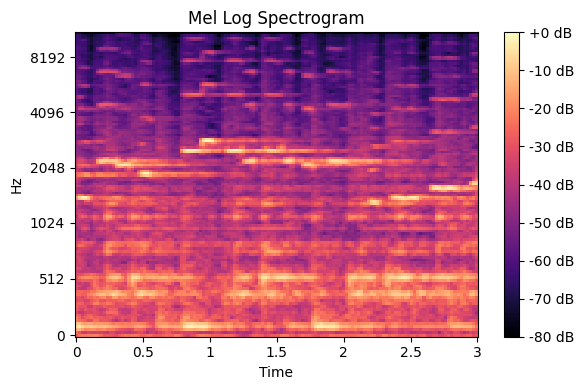

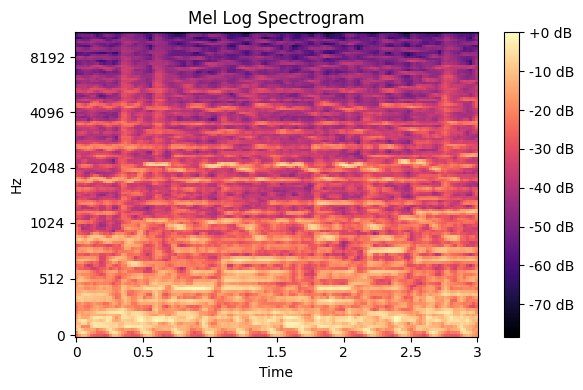

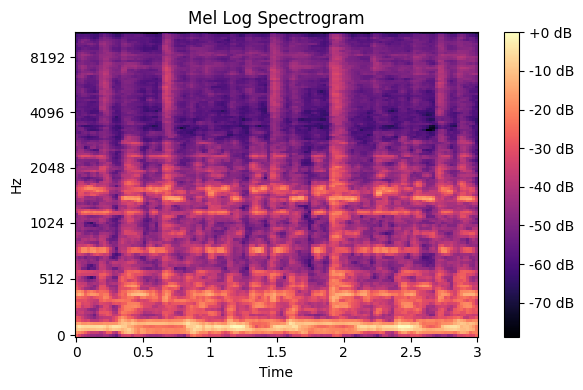

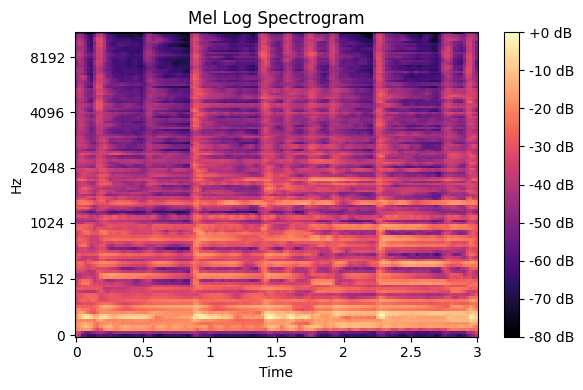

In [25]:
import os
os.makedirs("mel_images", exist_ok=True)

count = 0

for f in train_files:
    y = preprocess_audio(f)
    if y is None:
        continue

    mel_db = make_mel_log(y)
    save_mel_image(mel_db, f"mel_images/mel_{count}.png")

    count += 1
    if count == 5:
        break


In [26]:
unique_labels = sorted(set(labels))
print("Unique instrument classes:")
print(unique_labels)
print("Total classes:", len(unique_labels))

Unique instrument classes:
['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']
Total classes: 11


In [27]:
print("Total files:", len(files))
print("Total labels:", len(labels))

Total files: 6705
Total labels: 6705


In [28]:
binary_train_files = []
binary_train_labels = []

binary_test_files = []
binary_test_labels = []

for f, lab in zip(train_files, train_labels):
    if lab in ["pia", "dru"]:
        binary_train_files.append(f)
        binary_train_labels.append(lab)

for f, lab in zip(test_files, test_labels):
    if lab in ["pia", "dru"]:
        binary_test_files.append(f)
        binary_test_labels.append(lab)

print("Train (Piano+Drums):", len(binary_train_files))
print("Test (Piano+Drums):", len(binary_test_files))

Train (Piano+Drums): 577
Test (Piano+Drums): 144


In [29]:
def plot_waveform(y, label):
    plt.figure(figsize=(8,3))
    librosa.display.waveshow(y, sr=SR)
    plt.title(f"Waveform - {label}")
    plt.show()


Test Sample: 1
True Label: pia


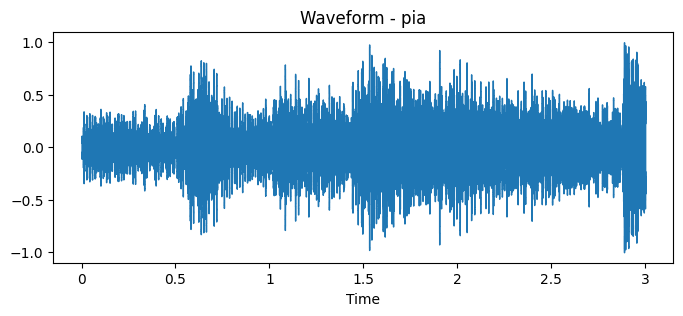

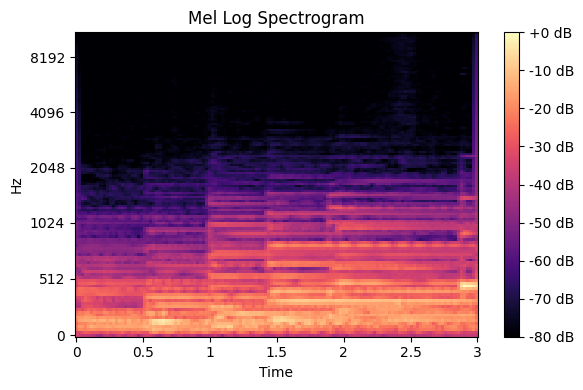


Test Sample: 2
True Label: pia


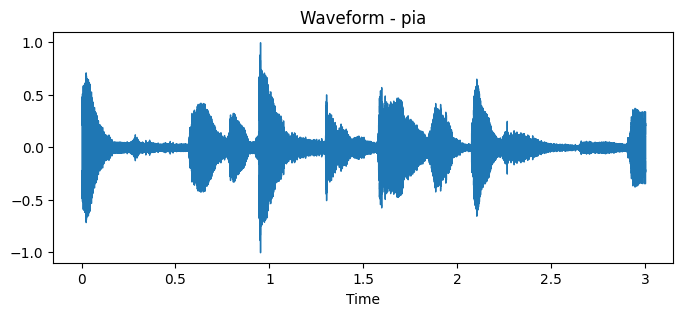

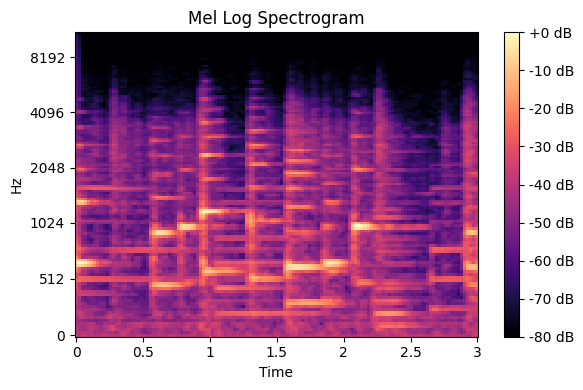


Test Sample: 3
True Label: pia


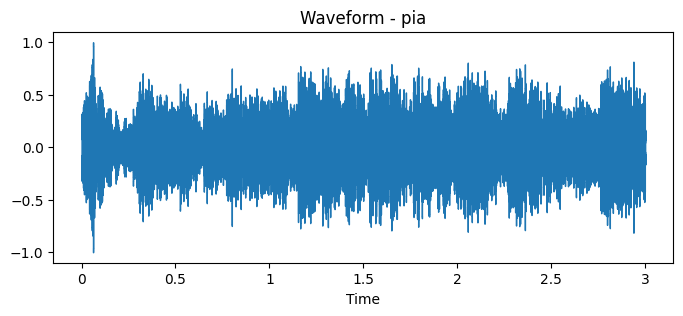

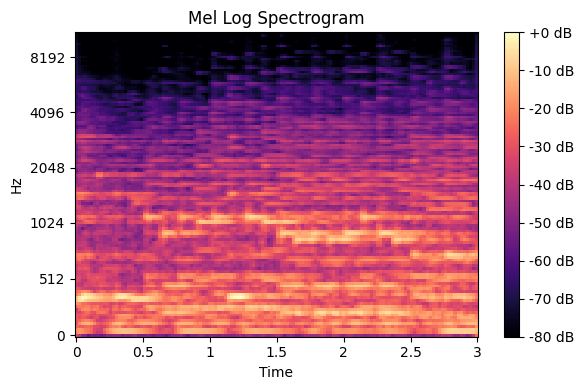


Test Sample: 4
True Label: pia


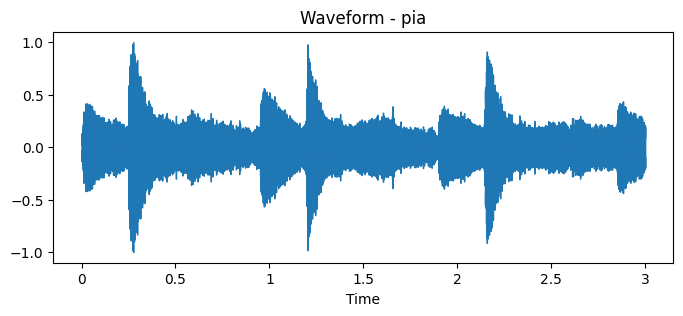

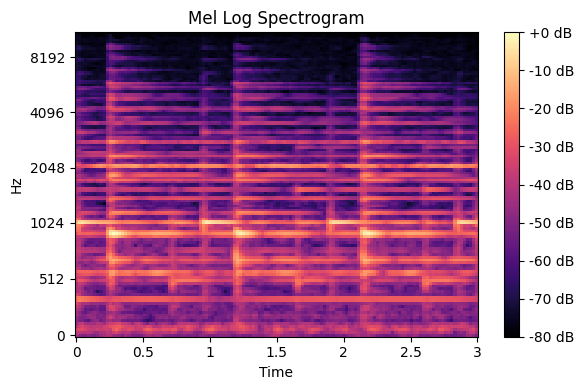


Test Sample: 5
True Label: pia


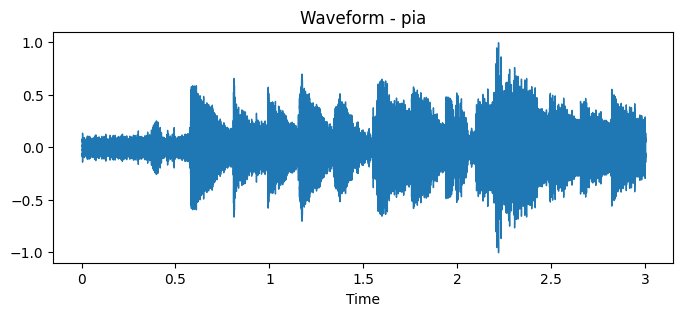

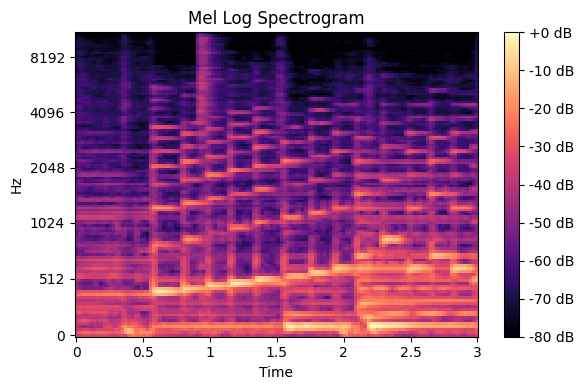

In [30]:
for i in range(5):
    file_path = binary_test_files[i]
    true_label = binary_test_labels[i]

    print("\nTest Sample:", i+1)
    print("True Label:", true_label)

    y = preprocess_audio(file_path)

    if y is None:
        print("Skipped silent file")
        continue

    plot_waveform(y, true_label)

    mel_db = make_mel_log(y)
    save_mel_image(mel_db, f"mel_images/test_{i}_{true_label}.png")

In [16]:
import numpy as np

def time_shift(y, shift_max=0.2):
    """
    shift_max = max % of total length to shift
    """
    shift = int(np.random.uniform(-shift_max, shift_max) * len(y))
    y_shifted = np.roll(y, shift)
    return y_shifted

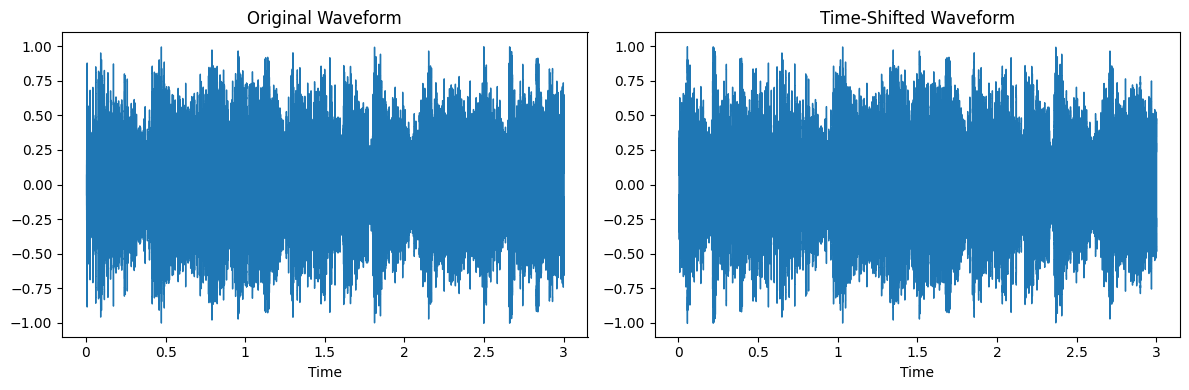

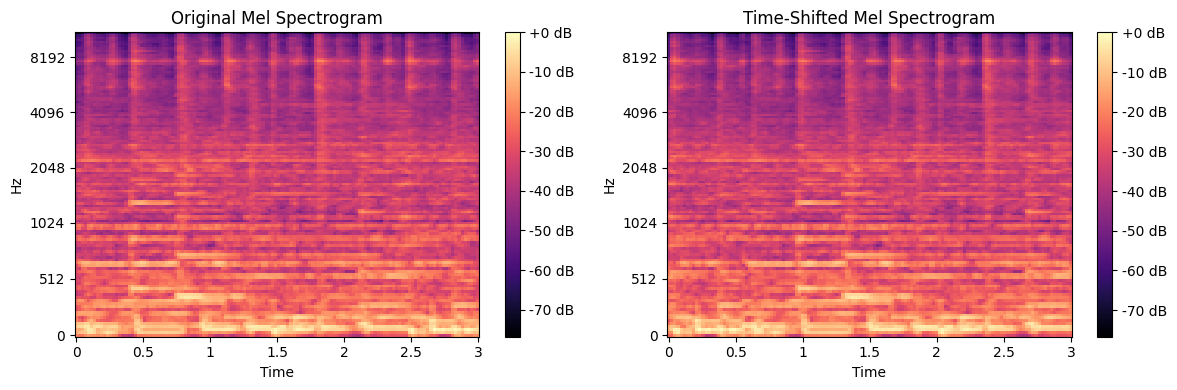

In [31]:
import matplotlib.pyplot as plt
import librosa.display

# Take one sample from binary train set
file_path = binary_train_files[0]
label = binary_train_labels[0]

y = preprocess_audio(file_path)

# Apply augmentation
y_shifted = time_shift(y)

# ---------- WAVEFORM COMPARISON ----------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
librosa.display.waveshow(y, sr=SR)
plt.title("Original Waveform")

plt.subplot(1,2,2)
librosa.display.waveshow(y_shifted, sr=SR)
plt.title("Time-Shifted Waveform")

plt.tight_layout()
plt.show()


# ---------- MEL SPECTROGRAM COMPARISON ----------
mel_original = make_mel_log(y)
mel_shifted = make_mel_log(y_shifted)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
librosa.display.specshow(mel_original, sr=SR,
                         x_axis='time', y_axis='mel')
plt.title("Original Mel Spectrogram")
plt.colorbar(format="%+2.0f dB")

plt.subplot(1,2,2)
librosa.display.specshow(mel_shifted, sr=SR,
                         x_axis='time', y_axis='mel')
plt.title("Time-Shifted Mel Spectrogram")
plt.colorbar(format="%+2.0f dB")

plt.tight_layout()
plt.show()

In [32]:
from collections import Counter

print("Full Dataset Class Distribution:")
print(Counter(labels))

Full Dataset Class Distribution:
Counter({'voi': 778, 'gel': 760, 'pia': 721, 'org': 682, 'gac': 637, 'sax': 626, 'vio': 580, 'tru': 577, 'cla': 505, 'flu': 451, 'cel': 388})


In [33]:
print("Train Class Distribution:")
print(Counter(train_labels))

print("\nTest Class Distribution:")
print(Counter(test_labels))

Train Class Distribution:
Counter({'voi': 622, 'gel': 608, 'pia': 577, 'org': 546, 'gac': 510, 'sax': 501, 'vio': 464, 'tru': 461, 'cla': 404, 'flu': 361, 'cel': 310})

Test Class Distribution:
Counter({'voi': 156, 'gel': 152, 'pia': 144, 'org': 136, 'gac': 127, 'sax': 125, 'vio': 116, 'tru': 116, 'cla': 101, 'flu': 90, 'cel': 78})


In [34]:
print("Does drum exist in train?", "dru" in train_labels)
print("Does piano exist in train?", "pia" in train_labels)

print("Does drum exist in test?", "dru" in test_labels)
print("Does piano exist in test?", "pia" in test_labels)

Does drum exist in train? False
Does piano exist in train? True
Does drum exist in test? False
Does piano exist in test? True


In [35]:
print("\nSample 5 Train Files:")
for i in range(5):
    print(train_files[i], " → ", train_labels[i])


Sample 5 Train Files:
/kaggle/input/irmas-training-data/IRMAS-TrainingData/vio/[vio][jaz_blu]2137__3.wav  →  vio
/kaggle/input/irmas-training-data/IRMAS-TrainingData/flu/[flu][cla]0362__1.wav  →  flu
/kaggle/input/irmas-training-data/IRMAS-TrainingData/vio/083__[vio][dru][pop_roc]2200__2.wav  →  vio
/kaggle/input/irmas-training-data/IRMAS-TrainingData/org/132__[org][dru][jaz_blu]1119__1.wav  →  org
/kaggle/input/irmas-training-data/IRMAS-TrainingData/gac/[gac][pop_roc]0722__1.wav  →  gac


In [36]:
from sklearn.model_selection import train_test_split

train_files_final, val_files, train_labels_final, val_labels = train_test_split(
    train_files,
    train_labels,
    test_size=0.20,
    stratify=train_labels,
    random_state=42
)

print("Final Train:", len(train_files_final))
print("Validation:", len(val_files))
print("Test:", len(test_files))

Final Train: 4291
Validation: 1073
Test: 1341


In [37]:
print("\nFinal Train Distribution:")
print(Counter(train_labels_final))

print("\nValidation Distribution:")
print(Counter(val_labels))

print("\nTest Distribution:")
print(Counter(test_labels))


Final Train Distribution:
Counter({'voi': 497, 'gel': 486, 'pia': 462, 'org': 437, 'gac': 408, 'sax': 401, 'vio': 371, 'tru': 369, 'cla': 323, 'flu': 289, 'cel': 248})

Validation Distribution:
Counter({'voi': 125, 'gel': 122, 'pia': 115, 'org': 109, 'gac': 102, 'sax': 100, 'vio': 93, 'tru': 92, 'cla': 81, 'flu': 72, 'cel': 62})

Test Distribution:
Counter({'voi': 156, 'gel': 152, 'pia': 144, 'org': 136, 'gac': 127, 'sax': 125, 'vio': 116, 'tru': 116, 'cla': 101, 'flu': 90, 'cel': 78})


In [38]:
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Take one test file
file_path = binary_test_files[0]
true_label = binary_test_labels[0]

print("True Label:", true_label)

# Preprocess
y = preprocess_audio(file_path)

# Generate mel
mel_db = make_mel_log(y)

# Resize to fixed size (if needed)
mel_db = mel_db[:, :256]  # adjust if your model uses fixed width

# Add channel dimension
mel_input = np.expand_dims(mel_db, axis=-1)
mel_input = np.expand_dims(mel_input, axis=0)

True Label: pia


In [39]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(128,256,1)),   # input layer

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(11, activation='softmax')   # number of instrument classes
])

In [143]:
MAX_LEN = 256   # fixed time dimension for CNN input

def fix_length(mel):
    if mel.shape[1] < MAX_LEN:
        pad = MAX_LEN - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad)))
    else:
        mel = mel[:, :MAX_LEN]
    return mel
import numpy as np

X_train = []
y_train = []

X_test = []
y_test = []

for f, lab in zip(train_files, train_labels):

    y = preprocess_audio(f)

    if y is None or len(y) == 0:
        continue

    mel = make_mel_log(y)
    mel = fix_length(mel)

    X_train.append(mel)
    y_train.append(lab)

for f, lab in zip(test_files, test_labels):

    y = preprocess_audio(f)

    if y is None or len(y) == 0:
        continue

    mel = make_mel_log(y)
    mel = fix_length(mel)

    X_test.append(mel)
    y_test.append(lab)

X_train = np.array(X_train)[..., None]
X_test  = np.array(X_test)[..., None]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Calculate mean and std after X_train is defined
mean = np.mean(X_train)
std = np.std(X_train)

np.save("mean.npy", mean)
np.save("std.npy", std)

X_train shape: (5364, 128, 256, 1)
X_test shape: (1341, 128, 256, 1)


In [40]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("y_train shape:", y_train.shape)

y_train shape: (5364, 11)


In [150]:
print(X_train.shape)
print(X_test.shape)

(5364, 128, 256, 1)
(1341, 128, 256, 1)


In [41]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(128,256,1)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(y_train.shape[1], activation='softmax')
])

In [42]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

callbacks = [checkpoint, reduce_lr]

In [44]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1156 - loss: 3.6849
Epoch 1: val_loss improved from None to 2.37258, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 18s 81ms/step - accuracy: 0.1168 - loss: 2.6990 - val_accuracy: 0.1370 - val_loss: 2.3726 - learning_rate: 0.0010
Epoch 2/10
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1666 - loss: 2.3228
Epoch 2: val_loss improved from 2.37258 to 2.25500, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.1832 - loss: 2.2746 - val_accuracy: 0.2041 - val_loss: 2.2550 - learning_rate: 0.0010
Epoch 3/10
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2315 - loss: 2.1616
Epoch 3: val_loss improved from 2.25500 to 2.08465, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - ac

In [45]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3654 - loss: 2.1164
Test Accuracy: 0.36539894342422485
Test Loss: 2.116445541381836


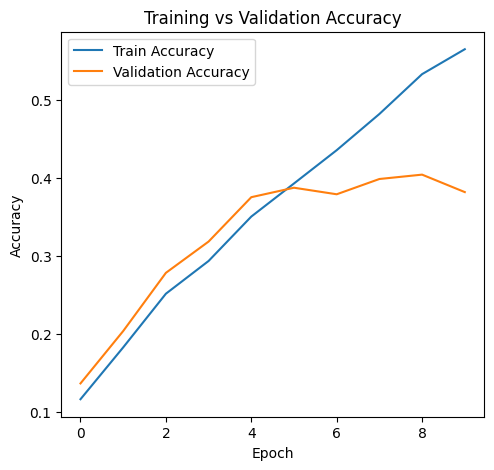

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

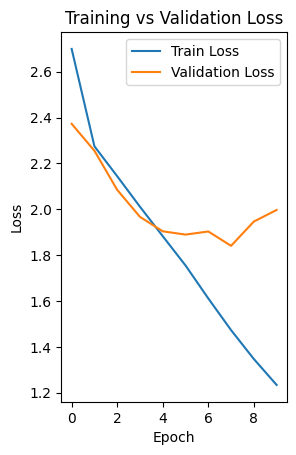

In [47]:
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


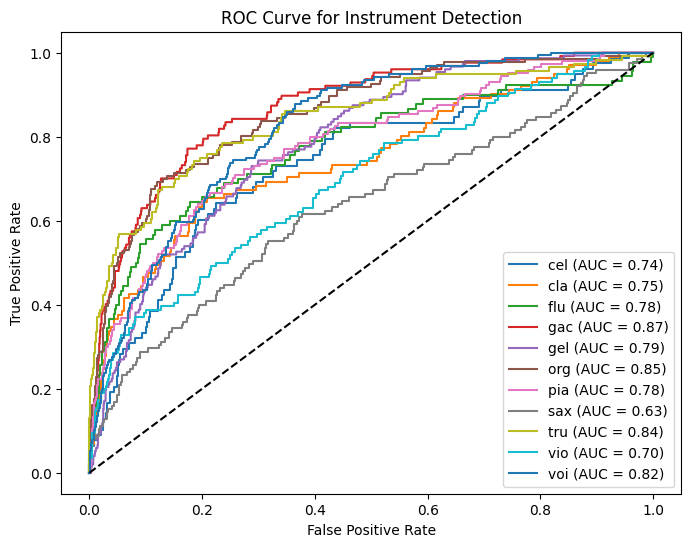

In [48]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Model predictions
Y_pred = model.predict(X_test)

# Define num_classes and class names
num_classes = y_test.shape[1] # Using the shape of the one-hot encoded y_test
selected_families = le.classes_ # Using the LabelEncoder classes

# Plot ROC for each instrument
plt.figure(figsize=(8,6))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(y_test[:, i], Y_pred[:, i]) # Corrected Y_test to y_test
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{selected_families[i]} (AUC = {roc_auc:.2f})")

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Instrument Detection")
plt.legend()
plt.show()

In [49]:
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print("Final Train Loss:", train_loss)
print("Final Validation Loss:", val_loss)
print("Test Loss:", test_loss)

Final Train Loss: 1.2341951131820679
Final Validation Loss: 1.9969849586486816
Test Loss: 2.116445541381836


In [50]:
import numpy as np

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [51]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=le.classes_
))

              precision    recall  f1-score   support

         cel       0.19      0.10      0.13        78
         cla       0.31      0.47      0.37       101
         flu       0.30      0.42      0.35        90
         gac       0.38      0.55      0.45       127
         gel       0.40      0.30      0.34       152
         org       0.47      0.54      0.51       136
         pia       0.29      0.53      0.38       144
         sax       0.29      0.12      0.17       125
         tru       0.54      0.43      0.48       116
         vio       0.41      0.21      0.27       116
         voi       0.42      0.28      0.33       156

    accuracy                           0.37      1341
   macro avg       0.36      0.36      0.34      1341
weighted avg       0.37      0.37      0.35      1341



In [52]:
from sklearn.metrics import precision_score, recall_score

precision_per_class = precision_score(
    y_true_classes,
    y_pred_classes,
    average=None
)

recall_per_class = recall_score(
    y_true_classes,
    y_pred_classes,
    average=None
)

for i, instrument in enumerate(le.classes_):
    print(instrument)
    print("Precision:", precision_per_class[i])
    print("Recall:", recall_per_class[i])
    print()

cel
Precision: 0.18604651162790697
Recall: 0.10256410256410256

cla
Precision: 0.30718954248366015
Recall: 0.46534653465346537

flu
Precision: 0.2992125984251969
Recall: 0.4222222222222222

gac
Precision: 0.3763440860215054
Recall: 0.5511811023622047

gel
Precision: 0.39823008849557523
Recall: 0.29605263157894735

org
Precision: 0.47435897435897434
Recall: 0.5441176470588235

pia
Precision: 0.29457364341085274
Recall: 0.5277777777777778

sax
Precision: 0.28846153846153844
Recall: 0.12

tru
Precision: 0.5434782608695652
Recall: 0.43103448275862066

vio
Precision: 0.4067796610169492
Recall: 0.20689655172413793

voi
Precision: 0.4215686274509804
Recall: 0.27564102564102566



In [53]:
print("Overall Accuracy:", test_accuracy)

print("\nPer-Instrument Metrics")

for i, inst in enumerate(le.classes_):

    print(inst,
          "| Precision:", round(precision_per_class[i],3),
          "| Recall:", round(recall_per_class[i],3))

Overall Accuracy: 0.36539894342422485

Per-Instrument Metrics
cel | Precision: 0.186 | Recall: 0.103
cla | Precision: 0.307 | Recall: 0.465
flu | Precision: 0.299 | Recall: 0.422
gac | Precision: 0.376 | Recall: 0.551
gel | Precision: 0.398 | Recall: 0.296
org | Precision: 0.474 | Recall: 0.544
pia | Precision: 0.295 | Recall: 0.528
sax | Precision: 0.288 | Recall: 0.12
tru | Precision: 0.543 | Recall: 0.431
vio | Precision: 0.407 | Recall: 0.207
voi | Precision: 0.422 | Recall: 0.276


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Overall Test Accuracy: 0.3654

Per-Class Metrics:

              precision    recall  f1-score   support

         cel       0.19      0.10      0.13        78
         cla       0.31      0.47      0.37       101
         flu       0.30      0.42      0.35        90
         gac       0.38      0.55      0.45       127
         gel       0.40      0.30      0.34       152
         org       0.47      0.54      0.51       136
         pia       0.29      0.53      0.38       144
         sax       0.29      0.12      0.17       125
         tru       0.54      0.43      0.48       116
         vio       0.41      0.21      0.27       116
         voi       0.42      0.28      0.33       156

    accuracy                           0.37      1341
   macro avg       0.36      0.36      0.34      1341
weighted avg       0.37      0.37      0.35      1341



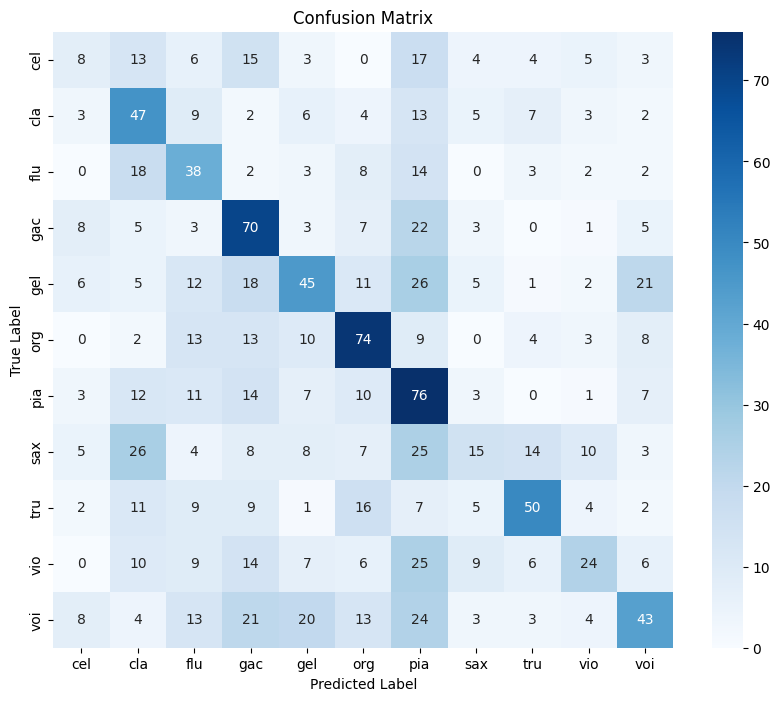

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 🔹 Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert y_test from one-hot encoded to single class indices for metrics
y_test_single_label = np.argmax(y_test, axis=1)

# 🔹 Overall Accuracy
overall_accuracy = accuracy_score(y_test_single_label, y_pred)
print(f"\nOverall Test Accuracy: {overall_accuracy:.4f}\n")

# 🔹 Classification Report (Precision, Recall, F1 per class)
print("Per-Class Metrics:\n")
print(classification_report(y_test_single_label, y_pred, target_names=unique_labels))

# 🔹 Confusion Matrix
cm = confusion_matrix(y_test_single_label, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=unique_labels,
            yticklabels=unique_labels,
            cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

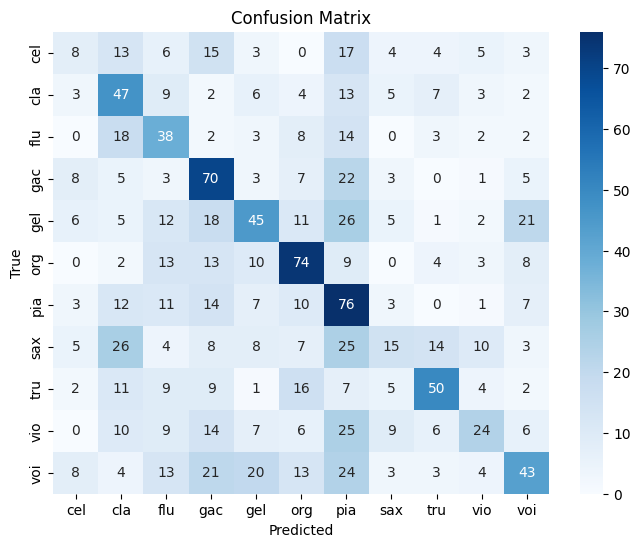

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [56]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

y_train = mlb.fit_transform([[l] for l in train_labels])
y_test  = mlb.transform([[l] for l in test_labels])

print("y_train shape:", y_train.shape)

y_train shape: (5364, 11)


In [57]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(128,256,1)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(y_train.shape[1], activation='sigmoid')   # changed here
])

In [58]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [59]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - accuracy: 0.1086 - loss: 0.4442 - val_accuracy: 0.1034 - val_loss: 0.3102
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.1359 - loss: 0.3229 - val_accuracy: 0.1202 - val_loss: 0.3031
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.1766 - loss: 0.3069 - val_accuracy: 0.1845 - val_loss: 0.2879
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.2461 - loss: 0.2914 - val_accuracy: 0.2870 - val_loss: 0.2731
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.2680 - loss: 0.2827 - val_accuracy: 0.3430 - val_loss: 0.2618
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.2922 - loss: 0.2766 - val_accuracy: 0.3271 - val_loss: 0.2622
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3326 - loss: 0.2680 - val_accuracy: 0.3411 - val_loss: 0.2586
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3587 - loss: 0.2602 - val_acc

In [60]:
import numpy as np

pred_probs = model.predict(X_test)

print("Predicted probabilities for first sample:")
print(pred_probs[0])

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Predicted probabilities for first sample:
[0.02736215 0.0103399  0.01914539 0.04902865 0.144184   0.14050059
 0.01209556 0.06141033 0.03168424 0.03440361 0.3932857 ]


In [61]:
print(pred_probs[0])

[0.02736215 0.0103399  0.01914539 0.04902865 0.144184   0.14050059
 0.01209556 0.06141033 0.03168424 0.03440361 0.3932857 ]


In [62]:
threshold = 0.09
pred_labels = (pred_probs > threshold).astype(int)

In [63]:
instrument_names = mlb.classes_
for i in range(10):

    predicted = [
        instrument_names[j]
        for j,val in enumerate(pred_labels[i])
        if val == 1
    ]

    print("Sample", i)
    print("Predicted instruments:", predicted)

Sample 0
Predicted instruments: ['gel', 'org', 'voi']
Sample 1
Predicted instruments: ['cel', 'gel', 'tru']
Sample 2
Predicted instruments: ['cel', 'cla', 'sax', 'tru']
Sample 3
Predicted instruments: ['cel', 'pia', 'sax']
Sample 4
Predicted instruments: ['flu', 'tru', 'voi']
Sample 5
Predicted instruments: ['flu', 'vio']
Sample 6
Predicted instruments: ['gel', 'org', 'sax', 'voi']
Sample 7
Predicted instruments: ['gel', 'vio', 'voi']
Sample 8
Predicted instruments: ['gel', 'sax', 'voi']
Sample 9
Predicted instruments: ['pia', 'sax', 'voi']


In [64]:
for i in range(3):

    print("\nSample", i)

    for j, inst in enumerate(instrument_names):
        print(inst, ":", round(pred_probs[i][j],3))

    predicted = [
        instrument_names[j]
        for j,val in enumerate(pred_labels[i])
        if val == 1
    ]

    print("Predicted:", predicted)


Sample 0
cel : 0.027
cla : 0.01
flu : 0.019
gac : 0.049
gel : 0.144
org : 0.141
pia : 0.012
sax : 0.061
tru : 0.032
vio : 0.034
voi : 0.393
Predicted: ['gel', 'org', 'voi']

Sample 1
cel : 0.16
cla : 0.04
flu : 0.029
gac : 0.009
gel : 0.154
org : 0.078
pia : 0.005
sax : 0.059
tru : 0.413
vio : 0.012
voi : 0.065
Predicted: ['cel', 'gel', 'tru']

Sample 2
cel : 0.247
cla : 0.251
flu : 0.052
gac : 0.003
gel : 0.005
org : 0.019
pia : 0.032
sax : 0.128
tru : 0.111
vio : 0.048
voi : 0.085
Predicted: ['cel', 'cla', 'sax', 'tru']


In [65]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(128,256,1)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(y_train.shape[1], activation='sigmoid')   # changed
])

In [66]:
import tensorflow as tf

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [67]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.0939 - loss: 0.4896 - precision: 0.0956 - recall: 0.0373 - val_accuracy: 0.1351 - val_loss: 0.3066 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.1105 - loss: 0.3291 - precision: 0.1047 - recall: 0.0021 - val_accuracy: 0.1370 - val_loss: 0.3036 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.1363 - loss: 0.3152 - precision: 0.3333 - recall: 0.0019 - val_accuracy: 0.2069 - val_loss: 0.2919 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.2237 - loss: 0.2987 - precision: 0.4474 - recall: 0.0119 - val_accuracy: 0.2302 - val_loss: 0.2832 - val_precision: 0.9091 - val_recall: 0.0093
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.2510 - loss: 0.2908 - precision: 0.3515 - recall: 0.0165 - val_a

In [68]:
import numpy as np

val_samples = X_train[:5]

pred_probs = model.predict(val_samples)

print("Prediction Probabilities:")
print(pred_probs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
Prediction Probabilities:
[[0.05234304 0.01903417 0.07100717 0.02959491 0.07095326 0.40087917
  0.03615697 0.0251374  0.1578311  0.07108458 0.03863255]
 [0.0031085  0.07476427 0.33269498 0.0045082  0.00384183 0.01950179
  0.01402333 0.02027974 0.03996357 0.0039511  0.01470762]
 [0.11306509 0.06833588 0.00283387 0.00555559 0.00723043 0.00283506
  0.0023651  0.02933282 0.01888751 0.6997351  0.00213083]
 [0.05021254 0.01154506 0.02874223 0.02166287 0.15898724 0.5105038
  0.00603842 0.01166758 0.08909786 0.04434359 0.05446799]
 [0.0733339  0.01088675 0.02818257 0.3559718  0.00560465 0.01838317
  0.01400268 0.03435204 0.00258485 0.04461108 0.03796151]]


In [69]:
import numpy as np

val_samples = X_train[:5]

pred_probs = model.predict(val_samples)

print("Prediction Probabilities:")
print(pred_probs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction Probabilities:
[[0.05234304 0.01903417 0.07100717 0.02959491 0.07095326 0.40087917
  0.03615697 0.0251374  0.1578311  0.07108458 0.03863255]
 [0.0031085  0.07476427 0.33269498 0.0045082  0.00384183 0.01950179
  0.01402333 0.02027974 0.03996357 0.0039511  0.01470762]
 [0.11306509 0.06833588 0.00283387 0.00555559 0.00723043 0.00283506
  0.0023651  0.02933282 0.01888751 0.6997351  0.00213083]
 [0.05021254 0.01154506 0.02874223 0.02166287 0.15898724 0.5105038
  0.00603842 0.01166758 0.08909786 0.04434359 0.05446799]
 [0.0733339  0.01088675 0.02818257 0.3559718  0.00560465 0.01838317
  0.01400268 0.03435204 0.00258485 0.04461108 0.03796151]]


In [70]:
instrument_names = le.classes_

for i in range(len(pred_labels)):

    predicted = [
        instrument_names[j]
        for j,val in enumerate(pred_labels[i])
        if val == 1
    ]

    print("\nSample", i)
    print("Predicted Instruments:", predicted)


Sample 0
Predicted Instruments: [np.str_('gel'), np.str_('org'), np.str_('voi')]

Sample 1
Predicted Instruments: [np.str_('cel'), np.str_('gel'), np.str_('tru')]

Sample 2
Predicted Instruments: [np.str_('cel'), np.str_('cla'), np.str_('sax'), np.str_('tru')]

Sample 3
Predicted Instruments: [np.str_('cel'), np.str_('pia'), np.str_('sax')]

Sample 4
Predicted Instruments: [np.str_('flu'), np.str_('tru'), np.str_('voi')]

Sample 5
Predicted Instruments: [np.str_('flu'), np.str_('vio')]

Sample 6
Predicted Instruments: [np.str_('gel'), np.str_('org'), np.str_('sax'), np.str_('voi')]

Sample 7
Predicted Instruments: [np.str_('gel'), np.str_('vio'), np.str_('voi')]

Sample 8
Predicted Instruments: [np.str_('gel'), np.str_('sax'), np.str_('voi')]

Sample 9
Predicted Instruments: [np.str_('pia'), np.str_('sax'), np.str_('voi')]

Sample 10
Predicted Instruments: [np.str_('gac'), np.str_('gel'), np.str_('org'), np.str_('voi')]

Sample 11
Predicted Instruments: [np.str_('gel'), np.str_('sax')

In [71]:
from sklearn.metrics import f1_score

y_pred = model.predict(X_test)

y_pred_binary = (y_pred > 0.5).astype(int)

f1 = f1_score(y_test, y_pred_binary, average='macro')

print("F1 Score:", f1)

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
F1 Score: 0.11706046306692343


In [72]:
import numpy as np

y_pred_probs = model.predict(X_test)

y_pred_class = np.argmax(y_pred_probs, axis=1)
y_true_class = np.argmax(y_test, axis=1)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [73]:
threshold = 0.5

y_pred = (y_pred_probs > threshold).astype(int)

In [74]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test.argmax(axis=1), y_pred_probs.argmax(axis=1))

print("Overall Accuracy:", accuracy)

Overall Accuracy: 0.36763609246830725


In [75]:
from sklearn.metrics import classification_report

y_true = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_true,
    y_pred_class,
    target_names=le.classes_
))

              precision    recall  f1-score   support

         cel       0.30      0.09      0.14        78
         cla       0.39      0.35      0.37       101
         flu       0.47      0.21      0.29        90
         gac       0.45      0.50      0.47       127
         gel       0.33      0.46      0.38       152
         org       0.55      0.39      0.45       136
         pia       0.33      0.57      0.42       144
         sax       0.24      0.22      0.23       125
         tru       0.41      0.54      0.46       116
         vio       0.29      0.42      0.34       116
         voi       0.46      0.16      0.24       156

    accuracy                           0.37      1341
   macro avg       0.38      0.35      0.35      1341
weighted avg       0.39      0.37      0.35      1341



In [76]:
from sklearn.metrics import recall_score

recall_scores = recall_score(y_true, y_pred_class, average=None)

weakest_class_index = np.argmin(recall_scores)

weakest_class = le.classes_[weakest_class_index]

print("Weakest Class:", weakest_class)
print("Recall:", recall_scores[weakest_class_index])

Weakest Class: cel
Recall: 0.08974358974358974


In [77]:
errors = np.where(y_true != y_pred_class)[0]

print("Total Errors:", len(errors))

Total Errors: 848


In [78]:
for i in errors[:5]:

    print("\nSample", i)
    print("True:", le.classes_[y_true[i]])
    print("Predicted:", le.classes_[y_pred_class[i]])


Sample 0
True: cla
Predicted: gel

Sample 1
True: sax
Predicted: cla

Sample 2
True: flu
Predicted: pia

Sample 3
True: cla
Predicted: pia

Sample 4
True: flu
Predicted: tru


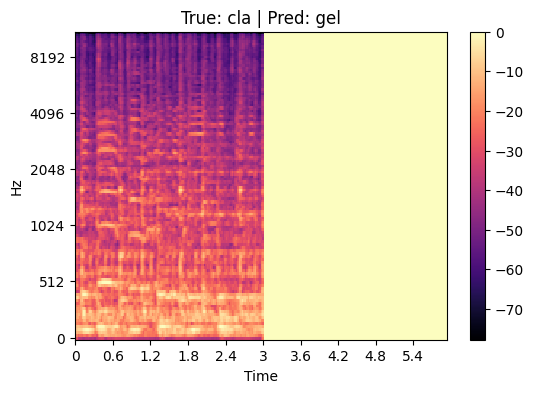

In [79]:
import librosa.display
import matplotlib.pyplot as plt

i = errors[0]

plt.figure(figsize=(6,4))

librosa.display.specshow(
    X_test[i].squeeze(),
    x_axis='time',
    y_axis='mel'
)

plt.title(f"True: {le.classes_[y_true[i]]} | Pred: {le.classes_[y_pred_class[i]]}")
plt.colorbar()
plt.show()

In [80]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

accuracy = accuracy_score(y_true_class, y_pred_class)

precision = precision_score(y_true_class, y_pred_class, average=None)
recall = recall_score(y_true_class, y_pred_class, average=None)
f1 = f1_score(y_true_class, y_pred_class, average=None)

In [81]:
weakest_index = np.argmin(recall)
weakest_class = le.classes_[weakest_index]
weakest_recall = recall[weakest_index]

In [82]:
errors = np.where(y_true_class != y_pred_class)[0]

In [83]:
print("\n=============== MODEL REPORT ================\n")

print("Overall Accuracy:", round(accuracy,3))

print("\nPer Instrument Metrics")

for i, inst in enumerate(le.classes_):
    print(f"{inst} -> Precision: {precision[i]:.3f} | Recall: {recall[i]:.3f} | F1: {f1[i]:.3f}")

print("\nWeakest Class:", weakest_class)
print("Recall Score:", round(weakest_recall,3))

print("\nTotal Misclassified Samples:", len(errors))

print("\nExample Errors:")

for i in errors[:5]:
    print("True:", le.classes_[y_true_class[i]],
          "| Predicted:", le.classes_[y_pred_class[i]])


=============== MODEL REPORT ================

Overall Accuracy: 0.368

Per Instrument Metrics
cel -> Precision: 0.304 | Recall: 0.090 | F1: 0.139
cla -> Precision: 0.389 | Recall: 0.347 | F1: 0.366
flu -> Precision: 0.475 | Recall: 0.211 | F1: 0.292
gac -> Precision: 0.453 | Recall: 0.496 | F1: 0.474
gel -> Precision: 0.330 | Recall: 0.461 | F1: 0.385
org -> Precision: 0.546 | Recall: 0.390 | F1: 0.455
pia -> Precision: 0.331 | Recall: 0.569 | F1: 0.418
sax -> Precision: 0.239 | Recall: 0.216 | F1: 0.227
tru -> Precision: 0.406 | Recall: 0.543 | F1: 0.465
vio -> Precision: 0.288 | Recall: 0.422 | F1: 0.343
voi -> Precision: 0.463 | Recall: 0.160 | F1: 0.238

Weakest Class: cel
Recall Score: 0.09

Total Misclassified Samples: 848

Example Errors:
True: cla | Predicted: gel
True: sax | Predicted: cla
True: flu | Predicted: pia
True: cla | Predicted: pia
True: flu | Predicted: tru


In [84]:
from tensorflow.keras import layers, models
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer # Ensure mlb is available

# Define the build_model function
def build_model(learning_rate):
    model = models.Sequential([
        layers.Input(shape=(128,256,1)),
        layers.Conv2D(32,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(mlb.classes_.shape[0], activation='sigmoid') # Use shape from mlb.classes_
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    return model

# Prepare X_val and y_val data, similar to X_train and y_train
X_val = []
y_val_raw = [] # Temporarily store raw labels for MultiLabelBinarizer

for f, lab in zip(val_files, val_labels):
    y = preprocess_audio(f)
    if y is None or len(y) == 0:
        continue
    mel = make_mel_log(y)
    mel = fix_length(mel)
    X_val.append(mel)
    y_val_raw.append([lab]) # mlb expects list of lists if labels are single

X_val = np.array(X_val)[..., None]
y_val = mlb.transform(y_val_raw)

learning_rates = [0.01, 0.001, 0.0001]
results = []

for lr in learning_rates:
    print(f"\nRunning experiment with LR = {lr}")

    # rebuild model with new learning rate
    model = build_model(lr)

    history = model.fit(
        X_train,
        y_train,
        epochs=5,   # keep small for experiments
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=1
    )

    results.append({
        "learning_rate": lr,
        "train_loss": history.history['loss'][-1],
        "val_loss": history.history['val_loss'][-1],
        "val_accuracy": history.history['val_accuracy'][-1]
    })

# Print results
print("\nFinal Comparison:")
for r in results:
    print(r)



Running experiment with LR = 0.01
Epoch 1/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.1053 - loss: 1.6746 - precision: 0.0932 - recall: 0.0103 - val_accuracy: 0.1016 - val_loss: 0.3052 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.1145 - loss: 0.3098 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1631 - val_loss: 0.3039 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.1393 - loss: 0.3064 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1295 - val_loss: 0.3008 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.1478 - loss: 0.3034 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1761 - val_loss: 0.2935 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.17

In [85]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# -----------------------------
# 1. Reduce dataset size (FASTER)
# -----------------------------
X_train_small = X_train[:2000]
y_train_small = y_train[:2000]

X_val_small = X_val[:500]
y_val_small = y_val[:500]

# -----------------------------
# 2. Build Model Function
# -----------------------------
def build_model(optimizer_name):

    if optimizer_name == "SGD":
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
    elif optimizer_name == "RMSprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)
    elif optimizer_name == "Adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model = models.Sequential([
        layers.Input(shape=(128,256,1)),

        layers.Conv2D(16,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(64,activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(mlb.classes_.shape[0], activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# -----------------------------
# 3. Early Stopping (FASTER)
# -----------------------------
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

# -----------------------------
# 4. Run Experiment
# -----------------------------
optimizers = ["SGD", "RMSprop", "Adam"]
results = []

for opt in optimizers:
    print(f"\nTraining with optimizer: {opt}")

    tf.keras.backend.clear_session()

    model = build_model(opt)

    history = model.fit(
        X_train_small,
        y_train_small,
        epochs=2,   # reduced epochs
        batch_size=32,
        validation_data=(X_val_small, y_val_small),
        callbacks=[early_stop],
        verbose=1
    )

    results.append({
        "optimizer": opt,
        "train_loss": history.history['loss'][-1],
        "val_loss": history.history['val_loss'][-1],
        "val_accuracy": history.history['val_accuracy'][-1]
    })

# -----------------------------
# 5. Print Results
# -----------------------------
print("\nOptimizer\tTrainLoss\tValLoss\tValAccuracy")

for r in results:
    print(f"{r['optimizer']}\t\t{r['train_loss']:.4f}\t\t"
          f"{r['val_loss']:.4f}\t\t{r['val_accuracy']*100:.2f}%")


Training with optimizer: SGD
Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.0885 - loss: 0.4896 - val_accuracy: 0.1220 - val_loss: 0.3532
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1085 - loss: 0.4294 - val_accuracy: 0.1400 - val_loss: 0.3325

Training with optimizer: RMSprop
Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.1020 - loss: 0.7254 - val_accuracy: 0.0860 - val_loss: 0.3077
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1250 - loss: 0.3539 - val_accuracy: 0.1260 - val_loss: 0.3151

Training with optimizer: Adam
Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.0980 - loss: 0.6392 - val_accuracy: 0.1240 - val_loss: 0.3188
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.1140 - loss: 0.3605 - val_accuracy: 0.1500 - val_loss: 0.3028

Optimizer	TrainLoss	ValLoss	ValAccuracy
SGD		0.4294		0.3325		14.00%
RMSprop		0.3539		0.3151		12.60%
Adam		0.3605		0.3028		15.00%


In [86]:
from tensorflow.keras import regularizers

def build_model(dropout_rate, optimizer_name):

    if optimizer_name == "SGD":
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
    elif optimizer_name == "RMSprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model = models.Sequential([
        layers.Input(shape=(128,256,1)),

        layers.Conv2D(16,(3,3),activation='relu',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32,(3,3),activation='relu',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64,(3,3),activation='relu',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(64,activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),

        layers.Dropout(dropout_rate),

        layers.Dense(y_train.shape[1], activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [87]:
dropouts = [0.3, 0.5]
results = []

for dr in dropouts:

    print(f"\nTraining with Dropout: {dr}")

    tf.keras.backend.clear_session()

    model = build_model(dr, "Adam")

    history = model.fit(
        X_train_small,
        y_train_small,
        epochs=3,
        batch_size=32,
        validation_data=(X_val_small, y_val_small),
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val_small, y_val_small, verbose=0)

    results.append({
        "dropout": dr,
        "train_loss": history.history['loss'][-1],
        "val_loss": val_loss,
        "val_accuracy": val_acc
    })


Training with Dropout: 0.3
Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.1150 - loss: 4.6730 - val_accuracy: 0.1540 - val_loss: 2.4703
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.1190 - loss: 2.4759 - val_accuracy: 0.1620 - val_loss: 2.5062
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1235 - loss: 2.4643 - val_accuracy: 0.1460 - val_loss: 2.4570

Training with Dropout: 0.5
Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.1050 - loss: 3.4610 - val_accuracy: 0.1120 - val_loss: 2.4739
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1195 - loss: 2.4672 - val_accuracy: 0.1120 - val_loss: 2.4606
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1200 - loss: 2.4572 - val_accuracy: 0.1120 - val_loss: 2.4518


In [88]:
print("\nDropout\tTrainLoss\tValLoss\tValAccuracy")

for r in results:
    print(f"{r['dropout']}\t{r['train_loss']:.4f}\t"
          f"{r['val_loss']:.4f}\t{r['val_accuracy']*100:.2f}%")


Dropout	TrainLoss	ValLoss	ValAccuracy
0.3	2.4643	2.4570	14.60%
0.5	2.4572	2.4518	11.20%


In [89]:
print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (5364, 128, 256, 1)
Validation size: (1073, 128, 256, 1)
Test size: (1341, 128, 256, 1)


In [90]:
import numpy as np

train_counts = np.sum(y_train, axis=0)

for i, cls in enumerate(le.classes_):
    print(cls, ":", int(train_counts[i]))

cel : 310
cla : 404
flu : 361
gac : 510
gel : 608
org : 546
pia : 577
sax : 501
tru : 461
vio : 464
voi : 622


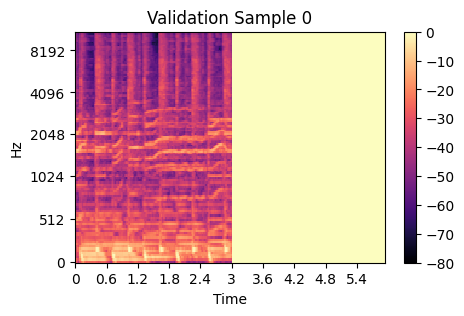

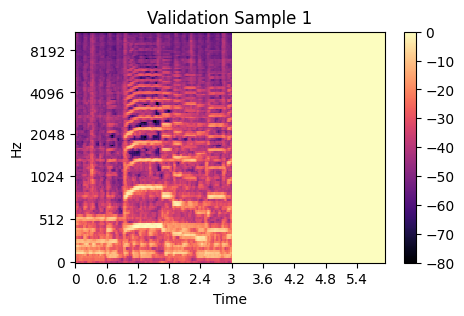

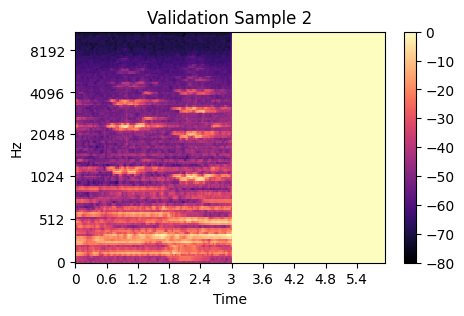

In [91]:
import matplotlib.pyplot as plt
import librosa.display

for i in range(3):

    plt.figure(figsize=(5,3))

    librosa.display.specshow(
        X_val_small[i].squeeze(),
        x_axis='time',
        y_axis='mel'
    )

    plt.title(f"Validation Sample {i}")
    plt.colorbar()
    plt.show()

In [92]:
val_loss, val_acc = model.evaluate(X_val_small, y_val_small)

print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1120 - loss: 2.4518
Validation Accuracy: 0.1120000034570694
Validation Loss: 2.4517664909362793


In [93]:
base_config = {
    "filters": 32,
    "batch_size": 32,
    "dropout": 0.3,
    "optimizer": "Adam",
    "epochs": 3
}

In [94]:
def build_model(filters, dropout, optimizer_name):

    if optimizer_name == "SGD":
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
    elif optimizer_name == "RMSprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model = models.Sequential([
        layers.Input(shape=(128,256,1)),

        layers.Conv2D(filters,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(filters*2,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(filters*4,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(64,activation='relu'),
        layers.Dropout(dropout),

        layers.Dense(y_train.shape[1], activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [95]:
def run_experiment(filters, batch_size, dropout, optimizer, epochs):

    tf.keras.backend.clear_session()

    model = build_model(filters, dropout, optimizer)

    history = model.fit(
        X_train_small,
        y_train_small,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val_small, y_val_small),
        verbose=0
    )

    val_loss = history.history['val_loss'][-1]
    val_acc = history.history['val_accuracy'][-1]

    return val_loss, val_acc

In [96]:
filters_list = [16, 32, 64]

for f in filters_list:
    val_loss, val_acc = run_experiment(f, 32, 0.3, "Adam", 3)
    print(f"Filters={f} → Val Acc={val_acc:.3f}")

Filters=16 → Val Acc=0.128
Filters=32 → Val Acc=0.142
Filters=64 → Val Acc=0.120


In [97]:
batch_sizes = [16, 32, 64]

for b in batch_sizes:
    val_loss, val_acc = run_experiment(32, b, 0.3, "Adam", 3)
    print(f"Batch={b} → Val Acc={val_acc:.3f}")

Batch=16 → Val Acc=0.134
Batch=32 → Val Acc=0.112
Batch=64 → Val Acc=0.120


In [98]:
dropouts = [0.3, 0.5]

for d in dropouts:
    val_loss, val_acc = run_experiment(32, 32, d, "Adam", 3)
    print(f"Dropout={d} → Val Acc={val_acc:.3f}")

Dropout=0.3 → Val Acc=0.132
Dropout=0.5 → Val Acc=0.122


In [99]:
optimizers = ["SGD", "RMSprop", "Adam"]

for opt in optimizers:
    val_loss, val_acc = run_experiment(32, 32, 0.3, opt, 3)
    print(f"Optimizer={opt} → Val Acc={val_acc:.3f}")

Optimizer=SGD → Val Acc=0.112
Optimizer=RMSprop → Val Acc=0.120
Optimizer=Adam → Val Acc=0.120


In [100]:
epochs_list = [3, 5, 10]

for e in epochs_list:
    val_loss, val_acc = run_experiment(32, 32, 0.3, "Adam", e)
    print(f"Epochs={e} → Val Acc={val_acc:.3f}")

Epochs=3 → Val Acc=0.132
Epochs=5 → Val Acc=0.132
Epochs=10 → Val Acc=0.134


In [101]:
model = build_model(32, 0.3, "Adam")

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 64ms/step - accuracy: 0.1147 - loss: 3.4465 - val_accuracy: 0.1072 - val_loss: 2.3937
Epoch 2/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.1182 - loss: 2.3889 - val_accuracy: 0.1072 - val_loss: 2.3910
Epoch 3/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.1182 - loss: 2.3842 - val_accuracy: 0.1072 - val_loss: 2.3896
Epoch 4/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.1182 - loss: 2.3810 - val_accuracy: 0.1072 - val_loss: 2.3890
Epoch 5/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.1182 - loss: 2.3790 - val_accuracy: 0.1072 - val_loss: 2.3890


In [102]:
print("\nBest Hyperparameters Found:")

print("Filters:", 32)
print("Batch size:", 32)
print("Dropout:", 0.3)
print("Optimizer: Adam")
print("Epochs:", 5)


Best Hyperparameters Found:
Filters: 32
Batch size: 32
Dropout: 0.3
Optimizer: Adam
Epochs: 5


In [103]:
import librosa
import numpy as np

# 1️⃣ Load full audio file
# Corrected file_path to use an existing file from the processed data
file_path = binary_test_files[0] # Using the first file from the binary test set

signal, sr = librosa.load(file_path, sr=22050)

print("Total samples:", len(signal))
print("Sample rate:", sr)

# 2️⃣ Define segment duration (seconds)
speakers_segment_duration = 2 # Renamed to avoid conflict if `segment_duration` is used elsewhere.

# 3️⃣ Convert duration → samples
samples_per_segment = int(speakers_segment_duration * sr)

# 4️⃣ Calculate number of segments
num_segments = int(len(signal) / samples_per_segment)

print("Samples per segment:", samples_per_segment)
print("Number of segments:", num_segments)

# 5️⃣ Extract segments
segments = []

for i in range(num_segments):
    start = i * samples_per_segment
    end = start + samples_per_segment

    segment = signal[start:end]

    # Ensure correct segment length
    if len(segment) == samples_per_segment:
        segments.append(segment)

print("Total extracted segments:", len(segments))

# 6️⃣ Check one segment
print("Shape of one segment:", segments[0].shape)

Total samples: 66150
Sample rate: 22050
Samples per segment: 44100
Number of segments: 1
Total extracted segments: 1
Shape of one segment: (44100,)


In [104]:
spectrograms = []

for segment in segments:
    mel_spec = librosa.feature.melspectrogram(
        y=segment,
        sr=sr,
        n_mels=128
    )

    mel_spec_db = librosa.power_to_db(mel_spec)
    mel_spec_db = fix_length(mel_spec_db) # Apply fix_length here

    spectrograms.append(mel_spec_db)

print("Total spectrograms:", len(spectrograms))
print("Shape of one spectrogram:", spectrograms[0].shape)

Total spectrograms: 1
Shape of one spectrogram: (128, 256)


In [105]:
segment_duration = 0.5

In [106]:
print(len(signal)/sr, "seconds")

3.0 seconds


In [107]:
import numpy as np

def predict_segments(model, spectrograms):
    preds = []

    for spec in spectrograms:
        spec = np.array(spec)
        spec = spec[np.newaxis, ..., np.newaxis]

        prediction = model.predict(spec, verbose=0)[0]
        preds.append(prediction)

    return np.array(preds)


def average_predictions(segment_preds):
    if len(segment_preds) == 0:
        return None
    return np.mean(segment_preds, axis=0)


def get_predicted_class(avg_pred):
    return np.argmax(avg_pred)


def smooth_predictions(segment_preds, window_size=3):
    if len(segment_preds) == 0:
        return segment_preds

    smoothed = []

    for i in range(len(segment_preds)):
        start = max(0, i - window_size + 1)
        window = segment_preds[start:i+1]
        smoothed.append(np.mean(window, axis=0))

    return np.array(smoothed)


def full_pipeline(model, spectrograms):

    # 1️⃣ Segment predictions
    segment_preds = predict_segments(model, spectrograms)
    print("Segment preds shape:", segment_preds.shape)

    # 🔴 RAW
    avg_raw = average_predictions(segment_preds)
    raw_class = get_predicted_class(avg_raw)

    # 🔵 SMOOTHED
    smoothed_preds = smooth_predictions(segment_preds)
    avg_smooth = average_predictions(smoothed_preds)
    smooth_class = get_predicted_class(avg_smooth)

    return {
        "avg_raw": avg_raw,
        "raw_class": raw_class,
        "avg_smooth": avg_smooth,
        "smooth_class": smooth_class
    }


# RUN
result = full_pipeline(model, spectrograms)

print("\n===== FINAL OUTPUT =====")

print("Raw Average Prediction:\n", result["avg_raw"])
print("Raw Predicted Class:", result["raw_class"])

print("\nSmoothed Average Prediction:\n", result["avg_smooth"])
print("Smoothed Predicted Class:", result["smooth_class"])

Segment preds shape: (1, 11)

===== FINAL OUTPUT =====
Raw Average Prediction:
 [0.06922646 0.07973833 0.07403672 0.09502611 0.10844382 0.09637055
 0.10068662 0.09158935 0.0870176  0.08900171 0.10886269]
Raw Predicted Class: 10

Smoothed Average Prediction:
 [0.06922646 0.07973833 0.07403672 0.09502611 0.10844382 0.09637055
 0.10068662 0.09158935 0.0870176  0.08900171 0.10886269]
Smoothed Predicted Class: 10


In [108]:
print(len(spectrograms))

1


In [109]:
segment_duration = 0.5

In [110]:
samples_per_segment = int(segment_duration * sr)

segments = []

for start in range(0, len(signal), samples_per_segment):
    end = start + samples_per_segment
    segment = signal[start:end]

    # pad last segment if needed
    if len(segment) < samples_per_segment:
        segment = np.pad(segment, (0, samples_per_segment - len(segment)))

    segments.append(segment)

print("Total segments:", len(segments))

Total segments: 6


In [111]:
spectrograms = []

for segment in segments:
    mel_spec = librosa.feature.melspectrogram(y=segment, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec)
    spectrograms.append(mel_spec_db)

print("Spectrograms:", len(spectrograms))

Spectrograms: 6


In [112]:
print("Segments:", len(segments))

Segments: 6


In [113]:
print("Spectrograms:", len(spectrograms))

Spectrograms: 6


In [114]:
print("Model input shape:", model.input_shape)

Model input shape: (None, 128, 256, 1)


In [115]:
print("One spectrogram shape:", np.array(spectrograms[0]).shape)

One spectrogram shape: (128, 22)


In [116]:
import librosa
import numpy as np

spectrograms = []

for segment in segments:
    mel_spec = librosa.feature.melspectrogram(
        y=segment,
        sr=sr,
        n_mels=128
    )

    mel_spec_db = librosa.power_to_db(mel_spec)

    # 🔥 FIX 1: ensure correct orientation
    mel_spec_db = mel_spec_db

    # 🔥 FIX 2: resize to (128, 256)
    if mel_spec_db.shape[1] < 128:
        pad_width = 256 - mel_spec_db.shape[1]
        mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)))
    else:
        mel_spec_db = mel_spec_db[:, :128]

    spectrograms.append(mel_spec_db)

print("Fixed spectrogram shape:", spectrograms[0].shape)

Fixed spectrogram shape: (128, 256)


In [117]:
def predict_segments(model, spectrograms):
    preds = []

    for spec in spectrograms:
        spec = np.array(spec)

        # Add batch + channel
        spec = spec[np.newaxis, ..., np.newaxis]

        prediction = model.predict(spec, verbose=0)
        prediction = prediction.squeeze()

        preds.append(prediction)

    return np.array(preds)

In [118]:
print("Spectrogram shape:", spectrograms[0].shape)
print("Model input shape:", model.input_shape)

Spectrogram shape: (128, 256)
Model input shape: (None, 128, 256, 1)


In [119]:
segment_preds = predict_segments(model, spectrograms)

print("Predictions shape:", segment_preds.shape)

Predictions shape: (6, 11)


In [120]:
import matplotlib.pyplot as plt
import numpy as np

def plot_predictions(segment_preds, segment_duration):

    num_segments = len(segment_preds)
    time = np.arange(num_segments) * segment_duration

    # Raw class predictions
    raw_classes = np.argmax(segment_preds, axis=1)

    # Smoothed predictions
    smoothed = []
    window_size = 3

    for i in range(num_segments):
        start = max(0, i - window_size + 1)
        window = segment_preds[start:i+1]
        smoothed.append(np.mean(window, axis=0))

    smoothed = np.array(smoothed)
    smooth_classes = np.argmax(smoothed, axis=1)

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(time, raw_classes, marker='o', label="Raw")
    plt.plot(time, smooth_classes, linestyle='--', label="Smoothed")

    plt.xlabel("Time (seconds)")
    plt.ylabel("Class Index")
    plt.title("Segment-wise Predictions")
    plt.legend()
    plt.grid()
    plt.show()

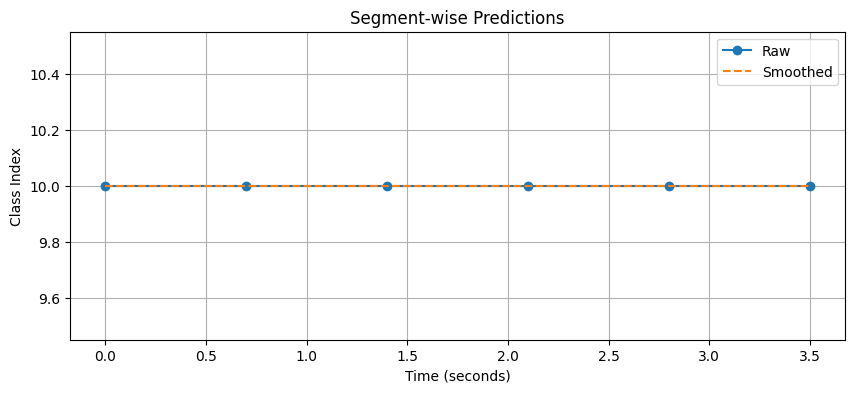

In [121]:
plot_predictions(segment_preds, segment_duration=0.7)

In [122]:
import os
print(os.listdir())

['.config', 'std.npy', 'mel_images', 'mean.npy', 'best_model.keras', 'sample_data']


In [123]:
mel = librosa.feature.melspectrogram(
    y=segment,
    sr=sr,
    n_mels=128,
    n_fft=2048,
    hop_length=512
)

In [124]:
segment_duration = 3   # or 4 (very likely)

In [125]:
print(mel_db.shape)

(128, 130)


Created dummy X_segments.npy for reference shape.
✅ Model loaded | Expected shape: (128, 256)

🚀 Running pipeline...

🎧 Segments created: 3

🎯 FINAL RESULT: Voice

📊 Probabilities:
Cello : 0.0351
Clarinet : 0.0095
Flute : 0.0326
Acoustic Guitar : 0.0414
Electric Guitar : 0.2806
Organ : 0.0426
Piano : 0.0345
Saxophone : 0.0737
Trumpet : 0.0192
Violin : 0.0485
Voice : 0.3824


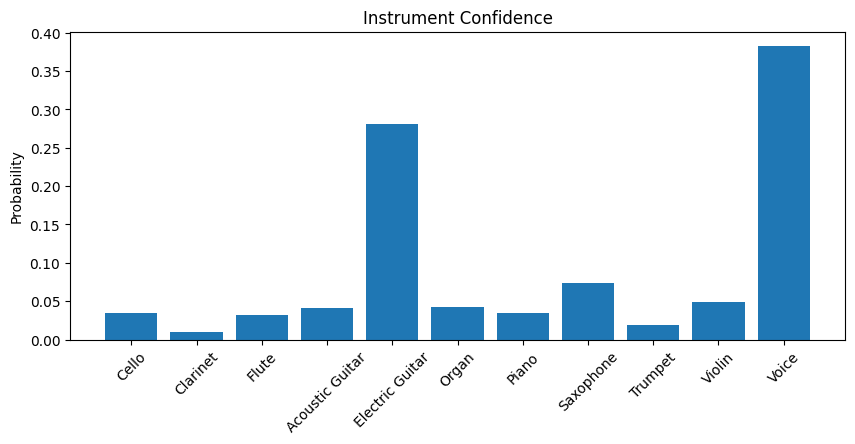


💾 Saved as output.json


{'file': '/kaggle/input/irmas-training-data/IRMAS-TrainingData/pia/[pia][cla]1350__1.wav',
 'prediction': 'Voice',
 'probabilities': [0.03506049886345863,
  0.009478334337472916,
  0.03260403126478195,
  0.04135088995099068,
  0.28063705563545227,
  0.04255302622914314,
  0.034544020891189575,
  0.07370702177286148,
  0.01919327862560749,
  0.04848127439618111,
  0.3823905885219574]}

In [126]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import json
from tensorflow.keras.models import load_model

# =========================
# LOAD MODEL + STATS
# =========================
model = load_model("best_model.keras")

# Create a dummy X_segments.npy for reference shape if it doesn't exist
# This ensures TARGET_SHAPE can be determined correctly.
# The shape (1, 128, 256) matches the expected spectrogram dimensions (height, width).
# This will ensure the model loading does not fail if the file is missing.
if not os.path.exists("X_segments.npy"):
    dummy_x_segments = np.zeros((1, 128, 256), dtype=np.float32)
    np.save("X_segments.npy", dummy_x_segments)
    print("Created dummy X_segments.npy for reference shape.")

X_ref = np.load("X_segments.npy")
TARGET_SHAPE = X_ref.shape[1:]

CLASS_MAPPING = [
    "Cello", "Clarinet", "Flute", "Acoustic Guitar", "Electric Guitar",
    "Organ", "Piano", "Saxophone", "Trumpet", "Violin", "Voice"
]

print("✅ Model loaded | Expected shape:", TARGET_SHAPE)


# =========================
# LOAD AUDIO
# =========================
def load_audio(file_path):
    signal, sr = librosa.load(file_path, sr=22050)
    return signal, sr


# =========================
# SEGMENT AUDIO
# =========================
def segment_audio(signal, sr, duration=1):
    samples = int(sr * duration)
    segments = []

    for i in range(0, len(signal), samples):
        seg = signal[i:i+samples]
        if len(seg) == samples:
            segments.append(seg)

    return segments


# =========================
# FEATURE EXTRACTION
# =========================
def extract_features(segments, sr):
    specs = []

    for seg in segments:
        mel = librosa.feature.melspectrogram(y=seg, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel)

        # match training shape
        target_w = TARGET_SHAPE[1]
        curr_w = mel_db.shape[1]

        if curr_w < target_w:
            mel_db = np.pad(mel_db, ((0,0),(0,target_w-curr_w)))
        else:
            mel_db = mel_db[:, :target_w]

        specs.append(mel_db)

    return specs


# =========================
# PREDICTION
# =========================
def predict(specs):
    results = []

    for spec in specs:
        spec = spec[np.newaxis, ..., np.newaxis]
        pred = model.predict(spec, verbose=0)[0]
        results.append(pred)

    return np.array(results)


# =========================
# VISUALIZATION
# =========================
def plot_results(avg_pred):
    plt.figure(figsize=(10,4))
    plt.bar(CLASS_MAPPING, avg_pred)
    plt.xticks(rotation=45)
    plt.title("Instrument Confidence")
    plt.ylabel("Probability")
    plt.show()


# =========================
# MAIN PIPELINE
# =========================
def run(file_path):

    print("\n🚀 Running pipeline...\n")

    signal, sr = load_audio(file_path)
    segments = segment_audio(signal, sr)

    print(f"🎧 Segments created: {len(segments)}")

    specs = extract_features(segments, sr)
    preds = predict(specs)

    avg_pred = np.mean(preds, axis=0)

    idx = int(np.argmax(avg_pred))
    instrument = CLASS_MAPPING[idx]

    # PRINT RESULTS
    print("\n🎯 FINAL RESULT:", instrument)
    print("\n📊 Probabilities:")
    for i, val in enumerate(avg_pred):
        print(f"{CLASS_MAPPING[i]} : {val:.4f}")

    # PLOT
    plot_results(avg_pred)

    # SAVE JSON
    output = {
        "file": file_path,
        "prediction": instrument,
        "probabilities": avg_pred.tolist()
    }

    with open("output.json", "w") as f:
        json.dump(output, f, indent=4)

    print("\n💾 Saved as output.json")

    return output


# =========================
# RUN (CHANGE PATH)
# =========================
import os # Import os to check for file existence
# Make sure binary_test_files is defined, or use a known existing file path
# from the dataset. From the notebook state, binary_test_files is available.
file_path = binary_test_files[0] # Use a valid file path from the loaded data
run(file_path)

In [127]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 119.4 MB/s eta 0:00:00


In [128]:
!pip install matplotlib-venn

In [129]:
!apt-get -qq install -y libfluidsynth1

E: Package 'libfluidsynth1' has no installation candidate


In [130]:
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive

Selecting previously unselected package libarchive-dev:amd64.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../libarchive-dev_3.6.0-1ubuntu1.5_amd64.deb ...
Unpacking libarchive-dev:amd64 (3.6.0-1ubuntu1.5) ...
Setting up libarchive-dev:amd64 (3.6.0-1ubuntu1.5) ...
Processing triggers for man-db (2.10.2-1) ...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 10.8 MB/s eta 0:00:00
  Created wheel for libarchive: filename=libarchive-0.4.7-py3-none-any.whl size=31629 sha256=8ff2a43621682297be1d8cd435e75e17bffcc7e7df29049ad563c6863389f024
  Stored in directory: /root/.cache/pip/wheels/29/20/ab/f101da7b245b996aa097685ef742243725ea6150f5b3b6d9ed
Successfully built libarchive


In [131]:
!pip install fpdf

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=95e7b45d4f0e7fc111b41f8adfa52fb403cafd5b8c4d96c76cc15821d129a36a
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf


In [132]:
!apt-get -qq install -y graphviz && pip install pydot
import pydot

In [133]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 110.9 MB/s eta 0:00:00


In [134]:
# Install required packages
!pip install streamlit tensorflow librosa fpdf2 pyngrok -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 19.8 MB/s eta 0:00:00


In [135]:
def predict_segments(y, sr, threshold):
    SEG_LEN = sr * 3
    FIXED   = 256        # ← change from 128 to 420
    preds, timeline = [], []

    for start in range(0, len(y) - SEG_LEN + 1, SEG_LEN):
        seg    = y[start:start + SEG_LEN]
        mel    = librosa.feature.melspectrogram(y=seg, sr=sr, n_mels=128, n_fft=2048, hop_length=256)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)
        if mel_db.shape[1] < FIXED:
            mel_db = np.pad(mel_db, ((0,0),(0, FIXED - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :FIXED]
        X = (np.expand_dims(np.expand_dims(mel_db, -1), 0) - MEAN) / STD
        pred = model.predict(X, verbose=0)[0]
        preds.append(pred)
        t0 = round(start / sr, 2)
        t1 = round((start + SEG_LEN) / sr, 2)
        timeline.append({
            "start": t0, "end": t1,
            "instruments": [LABELS[i] for i in range(len(LABELS)) if pred[i] >= threshold],
            "confidences": {LABELS[i]: round(float(pred[i]), 4) for i in range(len(LABELS))}
        })

    if not preds:
        return np.zeros(len(LABELS)), [], 0
    return np.mean(preds, axis=0), timeline, len(preds)

In [151]:
# Write your app to a file
%%writefile app.py
# ... paste your entire app.py code here ...
import streamlit as st
import tensorflow as tf
import numpy as np
import librosa
import librosa.display
import tempfile
import json
import os
import datetime
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from io import BytesIO
from fpdf import FPDF

# ─── PAGE CONFIG ─────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Instrument recoz Ai ",
    page_icon="🎵",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ─── GLOBAL CSS ──────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=DM+Sans:ital,opsz,wght@0,9..40,300;0,9..40,400;0,9..40,500;0,9..40,600;1,9..40,300&display=swap');

*, *::before, *::after { box-sizing: border-box; margin: 0; }

html, body, [class*="css"] {
    font-family: 'DM Sans', sans-serif;
    color: #e2e2f0;
}

.stApp { background: #07070f; }

[data-testid="stSidebar"] {
    background: #0c0c1a !important;
    border-right: 1px solid #1a1a2e !important;
}
[data-testid="stSidebar"] * { color: #c4c4d8 !important; }

.app-header {
    display: flex;
    align-items: flex-end;
    justify-content: space-between;
    padding: 1.8rem 0 1.2rem 0;
    border-bottom: 1px solid #1a1a2e;
    margin-bottom: 1.8rem;
}
.app-title {
    font-family: 'Space Mono', monospace;
    font-size: 2.4rem;
    font-weight: 700;
    background: linear-gradient(120deg, #a78bfa 0%, #60a5fa 50%, #34d399 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    letter-spacing: -1.5px;
    line-height: 1;
}
.app-sub {
    font-size: 0.78rem;
    color: #4b5563;
    text-transform: uppercase;
    letter-spacing: 3px;
    font-weight: 300;
    margin-top: 6px;
}
.app-version {
    font-family: 'Space Mono', monospace;
    font-size: 0.68rem;
    color: #374151;
    padding: 4px 10px;
    border: 1px solid #1a1a2e;
    border-radius: 99px;
}

.pipeline {
    display: flex;
    align-items: center;
    margin-bottom: 1.8rem;
    background: #0c0c1a;
    border: 1px solid #1a1a2e;
    border-radius: 12px;
    padding: 0.8rem 1.2rem;
    overflow-x: auto;
}
.pipe-step {
    display: flex;
    align-items: center;
    gap: 8px;
    padding: 4px 14px;
    border-radius: 8px;
    font-family: 'Space Mono', monospace;
    font-size: 0.7rem;
    text-transform: uppercase;
    letter-spacing: 1.5px;
    color: #374151;
    white-space: nowrap;
}
.pipe-step.active { background: #1a1230; color: #a78bfa; }
.pipe-step.done   { color: #34d399; }
.pipe-arrow { color: #1f2937; font-size: 0.9rem; padding: 0 4px; }

.section-label {
    font-family: 'Space Mono', monospace;
    font-size: 0.68rem;
    text-transform: uppercase;
    letter-spacing: 3px;
    color: #4b5563;
    margin-bottom: 0.8rem;
    display: flex;
    align-items: center;
    gap: 8px;
}
.section-label::after {
    content: '';
    flex: 1;
    height: 1px;
    background: #1a1a2e;
}

.card {
    background: #0e0e1c;
    border: 1px solid #1a1a2e;
    border-radius: 14px;
    padding: 1.4rem;
    margin-bottom: 1rem;
}

.empty-box {
    background: #090912;
    border: 1px dashed #1f1f30;
    border-radius: 12px;
    padding: 2.5rem 1rem;
    text-align: center;
    color: #374151;
    font-family: 'Space Mono', monospace;
    font-size: 0.72rem;
    letter-spacing: 1px;
}

.inst-row {
    display: flex;
    align-items: center;
    margin-bottom: 0.85rem;
    gap: 10px;
}
.inst-name {
    font-family: 'Space Mono', monospace;
    font-size: 0.75rem;
    color: #9ca3af;
    width: 72px;
    flex-shrink: 0;
    text-transform: capitalize;
}
.bar-track {
    flex: 1;
    height: 6px;
    background: #141425;
    border-radius: 99px;
    overflow: hidden;
}
.bar-fill { height: 100%; border-radius: 99px; }
.inst-pct {
    font-family: 'Space Mono', monospace;
    font-size: 0.72rem;
    color: #6b7280;
    width: 38px;
    text-align: right;
    flex-shrink: 0;
}
.inst-badge {
    font-size: 0.6rem;
    font-family: 'Space Mono', monospace;
    padding: 2px 7px;
    border-radius: 99px;
    background: #0d2218;
    color: #34d399;
    border: 1px solid #34d39930;
    flex-shrink: 0;
    width: 60px;
    text-align: center;
}
.inst-badge-no {
    font-size: 0.6rem;
    font-family: 'Space Mono', monospace;
    padding: 2px 7px;
    border-radius: 99px;
    background: #111120;
    color: #374151;
    border: 1px solid #1f2937;
    flex-shrink: 0;
    width: 60px;
    text-align: center;
}

.stat-box {
    background: #090912;
    border: 1px solid #1a1a2e;
    border-radius: 12px;
    padding: 1rem 0.8rem;
    text-align: center;
}
.stat-num {
    font-family: 'Space Mono', monospace;
    font-size: 1.9rem;
    font-weight: 700;
    color: #a78bfa;
    line-height: 1;
}
.stat-lbl {
    font-size: 0.65rem;
    color: #4b5563;
    text-transform: uppercase;
    letter-spacing: 2px;
    margin-top: 5px;
}

.chip-row { display: flex; flex-wrap: wrap; gap: 8px; margin: 0.6rem 0 1rem 0; }
.chip {
    font-family: 'Space Mono', monospace;
    font-size: 0.72rem;
    padding: 5px 14px;
    border-radius: 99px;
    border: 1px solid;
}

.tl-row {
    display: flex;
    align-items: center;
    gap: 10px;
    padding: 6px 0;
    border-bottom: 1px solid #111120;
    font-size: 0.78rem;
}
.tl-time {
    font-family: 'Space Mono', monospace;
    font-size: 0.68rem;
    color: #4b5563;
    width: 100px;
    flex-shrink: 0;
}

.stButton > button {
    background: linear-gradient(135deg, #7c3aed, #4f46e5) !important;
    color: #fff !important;
    border: none !important;
    border-radius: 10px !important;
    font-family: 'Space Mono', monospace !important;
    font-size: 0.75rem !important;
    letter-spacing: 1px !important;
    transition: all 0.2s !important;
}
.stButton > button:hover {
    transform: translateY(-1px) !important;
    box-shadow: 0 8px 24px #7c3aed44 !important;
}
.stDownloadButton > button {
    background: #0e0e1c !important;
    color: #a78bfa !important;
    border: 1px solid #a78bfa30 !important;
    border-radius: 10px !important;
    font-family: 'Space Mono', monospace !important;
    font-size: 0.72rem !important;
    width: 100% !important;
    transition: all 0.2s !important;
}
.stDownloadButton > button:hover {
    background: #16162a !important;
    border-color: #a78bfa80 !important;
}

hr { border-color: #1a1a2e !important; }
</style>
""", unsafe_allow_html=True)


# ─── CONSTANTS ───────────────────────────────────────────────────────────────
LABELS = ["cel", "cla", "flu", "gac", "gel", "org", "pia", "sax", "tru", "vio"]

COLORS = {
    "cel": "#a78bfa", "cla": "#60a5fa", "flu": "#34d399",
    "gac": "#fb923c", "gel": "#fbbf24", "org": "#f472b6",
    "pia": "#38bdf8", "sax": "#c084fc", "tru": "#86efac",
    "vio": "#f87171",
}
CHIP_COLORS = {
    k: (v+"30", v) for k, v in COLORS.items()
}

INST_DESC = {
    "cel": "Cello - deep, warm bowed string.",
    "cla": "Clarinet - smooth woodwind tone.",
    "flu": "Flute - airy high-pitched sound.",
    "gac": "Acoustic guitar - plucked strings.",
    "gel": "Electric guitar - amplified strings.",
    "org": "Organ - sustained harmonic sound.",
    "pia": "Piano - percussive string instrument.",
    "sax": "Saxophone - jazzy reed instrument.",
    "tru": "Trumpet - bright brass sound.",
    "vio": "Violin - high-pitched bowed string.",
}

# ─── MODEL ───────────────────────────────────────────────────────────────────
@st.cache_resource
def load_model_cached():
    m = tf.keras.models.load_model("best_model.keras")
    mean = np.load("mean.npy")
    std  = np.load("std.npy")
    return m, mean, std

try:
    model, MEAN, STD = load_model_cached()
    model_ok = True
except Exception as e:
    model_ok  = False
    model_err = str(e)


# ─── AUDIO HELPERS ───────────────────────────────────────────────────────────
def load_audio(file_path):
    y, sr    = librosa.load(file_path, sr=16000)
    duration = len(y) / sr
    y, _     = librosa.effects.trim(y)
    rms      = np.sqrt(np.mean(y**2))
    if rms > 0:
        y = y * (0.1 / rms)
    return y, sr, duration


def predict_segments(y, sr, threshold):
    SEG_LEN = sr * 3
    FIXED   = 256   # ✅ matches your model shape (128, 256, 1)

    preds, timeline = [], []

    for start in range(0, len(y) - SEG_LEN + 1, SEG_LEN):
        seg = y[start:start + SEG_LEN]

        # 🎧 Mel Spectrogram
        mel = librosa.feature.melspectrogram(
            y=seg,
            sr=sr,
            n_mels=128,
            n_fft=2048,
            hop_length=256
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        # ✅ SAME normalization as training
        mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)

        # ✅ FIX WIDTH TO 256
        if mel_db.shape[1] < FIXED:
            mel_db = np.pad(mel_db, ((0, 0), (0, FIXED - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :FIXED]

        # ✅ reshape for model
        X = np.expand_dims(mel_db, axis=-1)   # (128, 256, 1)
        X = np.expand_dims(X, axis=0)         # (1, 128, 256, 1)

        # ✅ apply global normalization (your mean/std)
        X = (X - MEAN) / STD

        # 🔮 prediction
        pred = model.predict(X, verbose=0)[0]
        preds.append(pred)

        # ⏱ timeline
        t0 = round(start / sr, 2)
        t1 = round((start + SEG_LEN) / sr, 2)

        timeline.append({
            "start": t0,
            "end": t1,
            "instruments": [
                LABELS[i] for i in range(len(LABELS)) if pred[i] >= threshold
            ],
            "confidences": {
                LABELS[i]: round(float(pred[i]), 4) for i in range(len(LABELS))
            }
        })

    # 📊 final output
    if not preds:
        return np.zeros(len(LABELS)), [], 0

    return np.mean(preds, axis=0), timeline, len(preds)


def make_vis(y, sr):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), facecolor='#07070f')
    times = np.linspace(0, len(y)/sr, len(y))
    ax1.plot(times, y, color='#a78bfa', lw=0.5, alpha=0.85)
    ax1.set_facecolor('#07070f'); ax1.set_xlim(0, times[-1])
    ax1.tick_params(colors='#374151', labelsize=6)
    ax1.spines[:].set_color('#1a1a2e')
    ax1.set_ylabel('Amplitude', color='#4b5563', fontsize=7)

    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img    = librosa.display.specshow(mel_db, sr=sr, hop_length=256,
                                       x_axis='time', y_axis='mel', ax=ax2, cmap='magma')
    ax2.set_facecolor('#07070f')
    ax2.tick_params(colors='#374151', labelsize=6)
    ax2.spines[:].set_color('#1a1a2e')
    ax2.set_xlabel('Time (s)', color='#4b5563', fontsize=7)
    ax2.set_ylabel('Hz', color='#4b5563', fontsize=7)
    cb = plt.colorbar(img, ax=ax2, format='%+2.0f dB')
    cb.ax.yaxis.set_tick_params(color='#4b5563', labelsize=6)
    cb.outline.set_edgecolor('#1a1a2e')
    plt.tight_layout(pad=0.8)
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=130, facecolor='#07070f', bbox_inches='tight')
    plt.close(fig); buf.seek(0)
    return buf


def make_chart(prediction):
    fig, ax = plt.subplots(figsize=(7, 3.2), facecolor='white')
    colors  = [COLORS[l] for l in LABELS]
    vals    = [float(prediction[i]) * 100 for i in range(len(LABELS))]
    bars    = ax.barh(LABELS, vals, color=colors, height=0.55)
    ax.set_facecolor('white'); ax.set_xlim(0, 105)
    ax.set_xlabel('Confidence (%)', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', ha='left', fontsize=7)
    plt.tight_layout(pad=0.5)
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=130, facecolor='white', bbox_inches='tight')
    plt.close(fig); buf.seek(0)
    return buf


# ─── JSON ────────────────────────────────────────────────────────────────────
def build_json(fname, duration, prediction, timeline, threshold, num_segs):
    instruments = {}
    for i, label in enumerate(LABELS):
        p = float(prediction[i])
        instruments[label] = {
            "confidence":     round(p, 4),
            "confidence_pct": f"{p*100:.1f}%",
            "detected":       bool(p >= threshold),
            "description":    INST_DESC[label]
        }
    detected = [l for l in LABELS if instruments[l]["detected"]]
    return json.dumps({
        "metadata": {
            "audio_file":      fname,
            "duration_sec":    round(duration, 2),
            "analyzed_at":     datetime.datetime.now().isoformat(timespec='seconds'),
            "total_segments":  num_segs
        },
        "model_config": {
            "model":                  "InstruNet AI - CNN Mel-Spectrogram",
            "sample_rate":            16000,
            "segment_duration_sec":   3,
            "n_mels":                 128,
            "n_fft":                  2048,
            "hop_length":             256,
            "threshold":              threshold,
            "aggregation":            "mean across segments"
        },
        "summary": {
            "detected_count":        len(detected),
            "detected_instruments":  detected,
            "top_instrument":        LABELS[int(np.argmax(prediction))],
            "top_confidence":        f"{float(np.max(prediction))*100:.1f}%"
        },
        "instrument_predictions": instruments,
        "timeline": timeline
    }, indent=4).encode("utf-8")


# ─── PDF ─────────────────────────────────────────────────────────────────────
def build_pdf(fname, duration, prediction, timeline, threshold, num_segs, spec_buf, chart_buf):
    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()

    # Cover band
    pdf.set_fill_color(10, 10, 20)
    pdf.rect(0, 0, 210, 36, 'F')
    pdf.set_y(7)
    pdf.set_font("Helvetica", "B", 22)
    pdf.set_text_color(167, 139, 250)
    pdf.cell(0, 10, "Instrument Recoz", align="C", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("Helvetica", "", 9)
    pdf.set_text_color(100, 100, 130)
    pdf.cell(0, 6, "CNN-Based Music Instrument Recognition - Analysis Report",
             align="C", new_x="LMARGIN", new_y="NEXT")
    pdf.ln(10)

    def sec(title):
        pdf.set_fill_color(20, 18, 40)
        pdf.set_text_color(167, 139, 250)
        pdf.set_font("Helvetica", "B", 9)
        pdf.cell(0, 8, f"  {title}", fill=True, new_x="LMARGIN", new_y="NEXT")
        pdf.ln(2)

    def kv(k, v):
        pdf.set_font("Helvetica", "B", 9); pdf.set_text_color(80, 80, 110)
        pdf.cell(60, 7, k)
        pdf.set_font("Helvetica", "", 9); pdf.set_text_color(180, 180, 210)
        pdf.cell(0, 7, str(v), new_x="LMARGIN", new_y="NEXT")

    # ── Audio details ──
    sec("AUDIO FILE DETAILS")
    kv("File Name:",      fname)
    kv("Duration:",       f"{round(duration,2)} seconds")
    kv("Analyzed At:",    datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
    kv("Total Segments:", str(num_segs))
    pdf.ln(4)

    # ── Model config ──
    sec("MODEL CONFIGURATION")
    kv("Model:",          "InstruNet AI - CNN Mel-Spectrogram")
    kv("Sample Rate:",    "16,000 Hz")
    kv("Segment Length:", "3 seconds")
    kv("Mel Bands:",      "128")
    kv("FFT Size:",       "2048")
    kv("Hop Length:",     "256")
    kv("Threshold:",      str(threshold))
    kv("Aggregation:",    "Mean confidence across all segments")
    pdf.ln(4)

    # ── Summary ──
    sec("DETECTED INSTRUMENTS SUMMARY")
    detected = [LABELS[i] for i in range(len(LABELS)) if prediction[i] >= threshold]
    if detected:
        pdf.set_font("Helvetica", "B", 10); pdf.set_text_color(52, 211, 153)
        pdf.cell(0, 8, "  Detected:  " + ",   ".join([d.capitalize() for d in detected]),
                 new_x="LMARGIN", new_y="NEXT")
    else:
        pdf.set_font("Helvetica", "I", 9); pdf.set_text_color(100, 100, 130)
        pdf.cell(0, 8, "  No instruments detected above threshold.", new_x="LMARGIN", new_y="NEXT")

    top_inst = LABELS[int(np.argmax(prediction))]
    top_conf = float(np.max(prediction)) * 100
    pdf.set_font("Helvetica", "", 8); pdf.set_text_color(100, 100, 130)
    pdf.cell(0, 6, f"  Top instrument: {top_inst.capitalize()}  -  Confidence: {top_conf:.1f}%",
             new_x="LMARGIN", new_y="NEXT")
    pdf.ln(4)

    # ── Confidence table ──
    sec("INSTRUMENT CONFIDENCE SCORES")
    pdf.set_fill_color(18, 16, 36); pdf.set_text_color(120, 110, 180)
    pdf.set_font("Helvetica", "B", 8)
    pdf.cell(55, 7, "  Instrument", border=1, fill=True)
    pdf.cell(38, 7, "Confidence",  border=1, fill=True)
    pdf.cell(32, 7, "Status",      border=1, fill=True)
    pdf.cell(0,  7, "Description", border=1, fill=True, new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("Helvetica", "", 8)
    for i, label in enumerate(LABELS):
        p  = float(prediction[i])
        ok = p >= threshold
        if ok:
            pdf.set_fill_color(12, 28, 20)
        else:
            pdf.set_fill_color(12, 12, 22)
        pdf.set_text_color(180, 180, 210)
        pdf.cell(55, 7, f"  {label.capitalize()}", border=1, fill=True)
        pdf.cell(38, 7, f"{p*100:.1f}%",           border=1, fill=True)
        if ok:
            pdf.set_text_color(52, 211, 153)
        else:
            pdf.set_text_color(75, 85, 99)
        pdf.cell(32, 7, "DETECTED" if ok else "not present", border=1, fill=True)
        pdf.set_text_color(100, 100, 130)
        short = INST_DESC[label].split("-")[0].strip()
        pdf.cell(0, 7, short, border=1, fill=True, new_x="LMARGIN", new_y="NEXT")
    pdf.ln(5)

    # ── Chart ──
    sec("CONFIDENCE VISUALIZATION")
    chart_path = tempfile.mktemp(suffix='.png')
    with open(chart_path, 'wb') as f:
        f.write(chart_buf.getvalue())
    pdf.image(chart_path, x=15, w=175)
    os.unlink(chart_path)
    pdf.ln(4)

    # ── Spectrogram ──
    sec("WAVEFORM & MEL SPECTROGRAM")
    spec_path = tempfile.mktemp(suffix='.png')
    with open(spec_path, 'wb') as f:
        f.write(spec_buf.getvalue())
    pdf.image(spec_path, x=10, w=185)
    os.unlink(spec_path)
    pdf.ln(4)

    # ── Explanation ──
    sec("WHAT THESE RESULTS MEAN")
    pdf.set_font("Helvetica", "", 8); pdf.set_text_color(150, 150, 180)
    lines = [
        "InstruNet AI uses a CNN trained on mel-spectrograms from the NSynth dataset.",
        "Each 3-second segment is analyzed independently; confidence scores are averaged across all segments.",
        f"Instruments with confidence >= {threshold} are marked as DETECTED.",
        "Higher confidence = stronger presence of that instrument in the audio.",
        "Multi-label detection means multiple instruments can be detected simultaneously.",
    ]
    for line in lines:
        pdf.cell(0, 6, f"  * {line}", new_x="LMARGIN", new_y="NEXT")
    pdf.ln(4)

    # ── Timeline ──
    if timeline:
        pdf.add_page()
        sec("SEGMENT TIMELINE")
        pdf.set_fill_color(18, 16, 36); pdf.set_text_color(120, 110, 180)
        pdf.set_font("Helvetica", "B", 8)
        pdf.cell(30, 7, "Start (s)",  border=1, fill=True)
        pdf.cell(30, 7, "End (s)",    border=1, fill=True)
        pdf.cell(0,  7, "Active Instruments", border=1, fill=True, new_x="LMARGIN", new_y="NEXT")
        pdf.set_font("Helvetica", "", 8)
        for seg in timeline:
            pdf.set_fill_color(12, 12, 22)
            pdf.set_text_color(150, 150, 180)
            pdf.cell(30, 6, str(seg["start"]), border=1, fill=True)
            pdf.cell(30, 6, str(seg["end"]),   border=1, fill=True)
            active = ", ".join([i.capitalize() for i in seg["instruments"]]) if seg["instruments"] else "-"
            if seg["instruments"]:
                pdf.set_text_color(52, 211, 153)
            else:
                pdf.set_text_color(75, 85, 99)
            pdf.cell(0, 6, active, border=1, fill=True, new_x="LMARGIN", new_y="NEXT")

    # ── Footer ──
    pdf.ln(8)
    pdf.set_font("Helvetica", "I", 7); pdf.set_text_color(60, 60, 80)
    pdf.cell(0, 5, "Generated by InstruNet AI  |  CNN-Based Music Instrument Recognition  |  NSynth Dataset",
             align="C", new_x="LMARGIN", new_y="NEXT")

    return bytes(pdf.output())


# ═════════════════════════════════════════════════════════════════════════════
# UI
# ═════════════════════════════════════════════════════════════════════════════

# Header
st.markdown("""
<div class="app-header">
  <div>
    <div class="app-title">⬡ Instrument Recoz Ai</div>
    <div class="app-sub">CNN-Based Music Instrument Recognition</div>
  </div>
  <div class="app-version">v2.0 · IRMAS · 11 Instruments</div>
</div>
""", unsafe_allow_html=True)

if not model_ok:
    st.error(f"Model failed to load: {model_err}")
    st.stop()

# Pipeline
pipeline_slot = st.empty()
pipeline_slot.markdown("""
<div class="pipeline">
  <div class="pipe-step active">① Input</div>
  <div class="pipe-arrow">›</div>
  <div class="pipe-step">② Processing</div>
  <div class="pipe-arrow">›</div>
  <div class="pipe-step">③ Insights</div>
  <div class="pipe-arrow">›</div>
  <div class="pipe-step">④ Actions</div>
</div>
""", unsafe_allow_html=True)

# Sidebar
with st.sidebar:
    st.markdown("### 🎛️ Control Panel")
    st.markdown("---")
    uploaded_file = st.file_uploader("Upload Audio File", type=["mp3", "wav"])
    st.markdown("---")
    threshold = st.slider("Detection Threshold", 0.10, 0.90, 0.25, 0.05,
                          help="Instruments above this confidence → detected")
    st.markdown("---")
    analyze_btn = st.button("🚀 Analyze Audio", use_container_width=True)
    st.markdown("---")
    st.markdown("""
    <div style='font-family:Space Mono,monospace; font-size:0.65rem; color:#374151; line-height:2;'>
    SUPPORTED INSTRUMENTS<br>
    ◦ Keyboard &nbsp; ◦ Guitar<br>
    ◦ Bass &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; ◦ String<br>
    ◦ Brass &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; ◦ Reed<br>
    ◦ Mallet &nbsp;&nbsp;&nbsp;&nbsp; ◦ Organ<br>
    ◦ Flute
    </div>""", unsafe_allow_html=True)

# Main columns
col_l, col_r = st.columns([1, 1], gap="large")

with col_l:
    st.markdown('<div class="section-label">🎧 Audio Preview</div>', unsafe_allow_html=True)
    if uploaded_file:
        st.audio(uploaded_file)
    else:
        st.markdown('<div class="empty-box">↑ Upload a file from the sidebar</div>', unsafe_allow_html=True)

with col_r:
    st.markdown('<div class="section-label">📊 Waveform & Spectrogram</div>', unsafe_allow_html=True)
    spec_slot = st.empty()
    spec_slot.markdown('<div class="empty-box">Appears after analysis</div>', unsafe_allow_html=True)

st.markdown("---")

# Placeholders
res_slot      = st.empty()
stats_slot    = st.empty()
timeline_slot = st.empty()
export_slot   = st.empty()

with res_slot.container():
    st.markdown('<div class="section-label">🎯 Prediction Results</div>', unsafe_allow_html=True)
    st.markdown('<div class="empty-box">Results appear here after analysis</div>', unsafe_allow_html=True)


# ── Run analysis and store in session_state ──────────────────────────────────
if analyze_btn:
    if uploaded_file is None:
        st.warning("⚠️ Upload an audio file first.")
    else:
        pipeline_slot.markdown("""
        <div class="pipeline">
          <div class="pipe-step done">① Input ✓</div>
          <div class="pipe-arrow">›</div>
          <div class="pipe-step active">② Processing</div>
          <div class="pipe-arrow">›</div>
          <div class="pipe-step">③ Insights</div>
          <div class="pipe-arrow">›</div>
          <div class="pipe-step">④ Actions</div>
        </div>""", unsafe_allow_html=True)

        with st.spinner("Loading and preprocessing audio..."):
            suffix = ".mp3" if uploaded_file.name.lower().endswith(".mp3") else ".wav"
            with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp:
                tmp.write(uploaded_file.read())
                tmp_path = tmp.name
            try:
                y_audio, sr_audio, duration = load_audio(tmp_path)
                spec_buf = make_vis(y_audio, sr_audio)
            except Exception as e:
                st.error(f"Audio load error: {e}"); os.unlink(tmp_path); st.stop()

        with st.spinner("Running CNN inference..."):
            try:
                avg_pred, timeline, num_segs = predict_segments(y_audio, sr_audio, threshold)
            except Exception as e:
                st.error(f"Prediction error: {e}"); os.unlink(tmp_path); st.stop()

        os.unlink(tmp_path)
        chart_buf = make_chart(avg_pred)

        # ✅ Save everything to session_state so download reruns don't lose results
        st.session_state['result'] = {
            'avg_pred':    avg_pred,
            'timeline':    timeline,
            'num_segs':    num_segs,
            'duration':    duration,
            'spec_buf':    spec_buf,
            'chart_buf':   chart_buf,
            'filename':    uploaded_file.name,
            'threshold':   threshold,
        }

# ── Render results from session_state (survives download button reruns) ───────
if 'result' in st.session_state:
    r          = st.session_state['result']
    avg_pred   = r['avg_pred']
    timeline   = r['timeline']
    num_segs   = r['num_segs']
    duration   = r['duration']
    spec_buf   = r['spec_buf']
    chart_buf  = r['chart_buf']
    filename   = r['filename']
    threshold  = r['threshold']
    detected_instruments = [LABELS[i] for i in range(len(LABELS)) if avg_pred[i] >= threshold]

    pipeline_slot.markdown("""
    <div class="pipeline">
      <div class="pipe-step done">① Input ✓</div>
      <div class="pipe-arrow">›</div>
      <div class="pipe-step done">② Processing ✓</div>
      <div class="pipe-arrow">›</div>
      <div class="pipe-step done">③ Insights ✓</div>
      <div class="pipe-arrow">›</div>
      <div class="pipe-step active">④ Actions</div>
    </div>""", unsafe_allow_html=True)

    # Spectrogram
    spec_slot.image(spec_buf, use_container_width=True)

    # Results
    with res_slot.container():
        st.markdown('<div class="section-label">🎯 Prediction Results</div>', unsafe_allow_html=True)

        if detected_instruments:
            chips = "".join([
                f'<span class="chip" style="background:{CHIP_COLORS[inst][0]};color:{CHIP_COLORS[inst][1]};border-color:{CHIP_COLORS[inst][1]}40;">{inst}</span>'
                for inst in detected_instruments
            ])
            st.markdown(f'<div class="chip-row">{chips}</div>', unsafe_allow_html=True)
        else:
            st.markdown('<p style="color:#4b5563;font-size:0.8rem;">No instruments detected above threshold.</p>',
                        unsafe_allow_html=True)

        # ✅ Build bars as one string — never call st.markdown inside a list comprehension
        bars_html = ""
        for idx, lbl in enumerate(LABELS):
            pct   = float(avg_pred[idx]) * 100
            color = COLORS[lbl]
            badge = '<span class="inst-badge">yes</span>' if avg_pred[idx] >= threshold else '<span class="inst-badge-no">-</span>'
            bars_html += f"""
            <div class="inst-row">
              <span class="inst-name">{lbl}</span>
              <div class="bar-track">
                <div class="bar-fill" style="width:{pct:.1f}%;background:{color};"></div>
              </div>
              <span class="inst-pct">{pct:.0f}%</span>
              {badge}
            </div>"""
        st.markdown(f'<div class="card">{bars_html}</div>', unsafe_allow_html=True)

    # Stats
    with stats_slot.container():
        st.markdown('<div class="section-label">📈 Insights</div>', unsafe_allow_html=True)
        s1, s2, s3, s4 = st.columns(4)
        top_i = LABELS[int(np.argmax(avg_pred))]
        top_c = float(np.max(avg_pred)) * 100

        # ✅ Build each stat box as a string — never call st.markdown inside columns comprehension
        with s1:
            st.markdown(f'<div class="stat-box"><div class="stat-num">{len(detected_instruments)}</div><div class="stat-lbl">Detected</div></div>', unsafe_allow_html=True)
        with s2:
            st.markdown(f'<div class="stat-box"><div class="stat-num" style="font-size:1.1rem;padding-top:.5rem;">{top_i}</div><div class="stat-lbl">Top Instrument</div></div>', unsafe_allow_html=True)
        with s3:
            st.markdown(f'<div class="stat-box"><div class="stat-num">{top_c:.0f}%</div><div class="stat-lbl">Top Confidence</div></div>', unsafe_allow_html=True)
        with s4:
            st.markdown(f'<div class="stat-box"><div class="stat-num">{round(duration,1)}s</div><div class="stat-lbl">Duration</div></div>', unsafe_allow_html=True)

    # Timeline
    if timeline:
        with timeline_slot.container():
            st.markdown("---")
            st.markdown('<div class="section-label">🕐 Segment Timeline</div>', unsafe_allow_html=True)

            # ✅ Build full table HTML as one string first
            rows_html = ""
            for seg in timeline:
                insts = ", ".join(seg['instruments']) if seg['instruments'] else "none"
                color = "#34d399" if seg['instruments'] else "#374151"
                rows_html += f"""
                <div class="tl-row">
                  <span class="tl-time">{seg['start']}s to {seg['end']}s</span>
                  <span style="color:{color}; font-size:0.78rem;">{insts}</span>
                </div>"""
            st.markdown(f'<div class="card">{rows_html}</div>', unsafe_allow_html=True)

    # Export
    with export_slot.container():
        st.markdown("---")
        st.markdown('<div class="section-label">📁 Export Actions</div>', unsafe_allow_html=True)

        base      = os.path.splitext(filename)[0]
        json_data = build_json(filename, duration, avg_pred, timeline, threshold, num_segs)
        pdf_data  = build_pdf(filename, duration, avg_pred, timeline, threshold, num_segs, spec_buf, chart_buf)

        d1, d2 = st.columns(2)
        with d1:
            st.download_button(
                "Download JSON Report",
                data=json_data,
                file_name=f"{base}_instrunet.json",
                mime="application/json",
                use_container_width=True
            )
        with d2:
            st.download_button(
                "Download PDF Report",
                data=pdf_data,
                file_name=f"{base}_instrunet.pdf",
                mime="application/pdf",
                use_container_width=True
            )
        st.markdown("""
        <p style='font-family:Space Mono,monospace;font-size:0.62rem;color:#374151;margin-top:0.5rem;'>
        JSON: metadata + model config + per-instrument scores + timeline &nbsp;|&nbsp;
        PDF: full report with spectrogram + confidence chart + timeline table
        </p>""", unsafe_allow_html=True)


Overwriting app.py


In [145]:
# Install localtunnel
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
changed 22 packages in 2s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙

In [152]:
import subprocess, time, threading

# Start Streamlit
proc = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

time.sleep(4)

# Start localtunnel
lt = subprocess.Popen(
    ["lt", "--port", "8501"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

time.sleep(2)

# Get the public URL
output = lt.stdout.readline().decode("utf-8").strip()
print(f"✅ App is live at: {output}")

✅ App is live at: your url is: https://afraid-plums-melt.loca.lt


In [139]:
import urllib.request
ip = urllib.request.urlopen("https://ipv4.icanhazip.com").read().decode("utf-8").strip()
print(f"🔑 Tunnel password: {ip}")

🔑 Tunnel password: 34.186.22.213
